# Multi-simulation H-R and CMD spread-metric analysis

Jupytext percent-format script. Convert it to a notebook with:

```bash
jupytext --to notebook multi_sim_cmd_spread_analysis.py
```

This version compares seed 00 for:

- cloud surface density 0.1 g cm^-2;
- cloud surface density 1.0 g cm^-2;
- epsilon_ff = 0.01, 0.03, 0.10, 0.30, and 1.00.

The analysis is performed in:

1. log(L/Lsun) versus Teff;
2. F070W-F200W versus F200W.

The H-R spread metric uses six fixed 100 K bins from 3000 to 3600 K.
The CMD spread metric uses six fixed equal-width color bins. Its outer
boundaries are the F070W-F200W colors corresponding to 3000 K and 3600 K
on the 1 Myr isochrone.

The script:

- builds or loads the 1-20 Myr photometric isochrone grid;
- creates five-panel cluster-evolution figures at 1, 5, 10, 15, and 20 Myr
  for every density/epsilon_ff combination;
- measures the spread metric every 0.5 Myr;
- creates one grouped H-R spread-evolution figure and one grouped CMD
  spread-evolution figure, each separated into density panels;
- exports summary and per-bin CSV tables.

In [1]:
from __future__ import annotations

import contextlib
import io
import math
import os
import shutil
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append("/home/wyz5rge/synthetic-cmd-dev/cmd_generator")
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
UPDATED_MERGED_ROOT = Path(
    "/home/wyz5rge/SPISEA/evolution/merged/"
    "baraffe_pisa_ekstrom_parsec/"
)

SIMULATION_ROOT = Path(
    "/standard/Tan_JC/backup_protoclusters/multiples/M3000new"
)

# Directory names under M3000new. The density-1.0 spelling is resolved from
# several common candidates. Add another candidate if your cluster differs.
SIGMA_DIR_CANDIDATES = {
    0.1: ("sigma0p1",),
    1.0: ("sigma1p0", "sigma1", "sigma1p00"),
}


def resolve_sigma_dir(density: float) -> str:
    """Return the first existing directory name for a cloud density."""
    candidates = SIGMA_DIR_CANDIDATES[density]

    for candidate in candidates:
        if (SIMULATION_ROOT / candidate).is_dir():
            return candidate

    # Preserve a useful path in diagnostics if none of the candidates exist.
    return candidates[0]


SIGMA_DIRS = {
    density: resolve_sigma_dir(density)
    for density in SIGMA_DIR_CANDIDATES
}

EFF_DIRS = {
    0.01: "sfe_ff001",
    0.03: "sfe_ff003",
    0.10: "sfe_ff010",
    0.30: "sfe_ff030",
    1.00: "sfe_ff100",
}

SEED = "00"

ISO_CACHE_DIR = Path.cwd() / "isochrone_cache"
OUTPUT_DIR = Path.cwd() / "multi_sim_cmd_spread_outputs"

RESET_ISO_CACHE = False
SAVE_FIGURES = True
SHOW_FIGURES = True

USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0

ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1.0e6)

EVOLUTION_TIMES_MYR = np.array([1.0, 5.0, 10.0, 15.0, 20.0])
ANALYSIS_TIMES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)

TEFF_MIN_K = 3000.0
TEFF_MAX_K = 3600.0
N_BINS = 6
TEFF_BIN_EDGES_K = np.linspace(TEFF_MIN_K, TEFF_MAX_K, N_BINS + 1)

MIN_STARS_PER_BIN = 8
QUARTILE_FRACTION = 0.25
L_SUN_WATTS = 3.846e26

# The evolutionary grid begins at 1 Myr. Stars younger than this occur in
# early cluster snapshots, so evaluate them on the youngest available
# isochrone instead of dropping them from the sample.
CLIP_YOUNG_STARS_TO_GRID_MINIMUM = True

INTERPOLATED_COLUMNS = [
    "system_index",
    "mass",
    "age_myr",
    "age_used_myr",
    "age_clipped_to_grid",
    "teff",
    "luminosity_watts",
    "log_luminosity_lsun",
    "logg",
    "mag_F070W",
    "mag_F200W",
    "color_F070W_F200W",
]

ALL_FILTERS = [
    "jwst,F070W",
    "jwst,F200W",
]

FILTER_KEYS = {
    "F070W": "m_jwst_F070W",
    "F200W": "m_jwst_F200W",
}

CMD_NAME = "F070W-F200W"
CMD_COLOR_LABEL = "F070W - F200W"
CMD_Y_LABEL = "F200W"

## Simulation definitions

In [3]:
@dataclass(frozen=True)
class SimulationConfig:
    density: float
    epsilon_ff: float
    seed: str
    path: Path

    @property
    def label(self) -> str:
        return (
            rf"$\Sigma_{{\rm cloud}}={self.density:g}$, "
            rf"$\epsilon_{{\rm ff}}={self.epsilon_ff:.2f}$"
        )

    @property
    def file_tag(self) -> str:
        density_tag = str(self.density).replace(".", "p")
        eff_tag = f"{self.epsilon_ff:.2f}".replace(".", "p")
        return f"sigma{density_tag}_eff{eff_tag}_seed{self.seed}"


def build_simulation_configs() -> list[SimulationConfig]:
    configs: list[SimulationConfig] = []

    for density, sigma_dir in SIGMA_DIRS.items():
        for epsilon_ff, eff_dir in EFF_DIRS.items():
            path = (
                SIMULATION_ROOT
                / sigma_dir
                / "fiducial"
                / eff_dir
                / SEED
            )
            configs.append(
                SimulationConfig(
                    density=density,
                    epsilon_ff=epsilon_ff,
                    seed=SEED,
                    path=path,
                )
            )

    return configs


SIMULATIONS = build_simulation_configs()

print("Configured simulations:")
for sim in SIMULATIONS:
    print(f"  {sim.label}: {sim.path}")

Configured simulations:
  $\Sigma_{\rm cloud}=0.1$, $\epsilon_{\rm ff}=0.01$: /standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff001/00
  $\Sigma_{\rm cloud}=0.1$, $\epsilon_{\rm ff}=0.03$: /standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff003/00
  $\Sigma_{\rm cloud}=0.1$, $\epsilon_{\rm ff}=0.10$: /standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff010/00
  $\Sigma_{\rm cloud}=0.1$, $\epsilon_{\rm ff}=0.30$: /standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff030/00
  $\Sigma_{\rm cloud}=0.1$, $\epsilon_{\rm ff}=1.00$: /standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff100/00
  $\Sigma_{\rm cloud}=1$, $\epsilon_{\rm ff}=0.01$: /standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma1p0/fiducial/sfe_ff001/00
  $\Sigma_{\rm cloud}=1$, $\epsilon_{\rm ff}=0.03$: /standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma1p0/fiducial

## Merged-model ASCII compatibility reader

In [4]:
class MergedBaraffePisaEkstromParsecDAT:
    """Compatibility reader for merged ``iso_*.dat`` evolutionary tracks."""

    def __init__(self, root_dir: Path | str, rot: bool = False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)

        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list: list[float] = []

        self.grid_dir = self.root_dir / (
            "z015_rot" if self.rot else "z015_norot"
        )

        if not self.grid_dir.is_dir():
            raise FileNotFoundError(
                f"Merged-model directory does not exist: {self.grid_dir}"
            )

        paths = sorted(self.grid_dir.glob("iso_*.dat"))
        if not paths:
            raise FileNotFoundError(
                f"No iso_*.dat files found in {self.grid_dir}"
            )

        self.age_file_map: dict[float, Path] = {}

        for path in paths:
            try:
                log_age = float(path.stem.split("_")[1])
            except (IndexError, ValueError):
                continue

            self.age_file_map[round(log_age, 2)] = path

        self.age_list = np.array(
            sorted(self.age_file_map),
            dtype=float,
        )

    def isochrone(
        self,
        age: float = 1.0e6,
        metallicity: float = 0.0,
    ) -> Table:
        log_age_requested = math.log10(age)

        if log_age_requested < self.age_list[0]:
            raise ValueError(
                f"Requested logAge={log_age_requested:.4f} is below "
                f"grid minimum {self.age_list[0]:.2f}."
            )

        if log_age_requested > self.age_list[-1]:
            raise ValueError(
                f"Requested logAge={log_age_requested:.4f} is above "
                f"grid maximum {self.age_list[-1]:.2f}."
            )

        idx = int(
            np.argmin(
                np.abs(self.age_list - log_age_requested)
            )
        )
        selected_log_age = float(self.age_list[idx])
        iso_path = self.age_file_map[round(selected_log_age, 2)]

        dtype = [
            ("mass", "f8"),
            ("logT", "f8"),
            ("logL", "f8"),
            ("logg", "f8"),
            ("logT_WR", "f8"),
            ("mass_current", "f8"),
            ("phase", "i4"),
            ("model_ref", "U32"),
        ]

        data = np.genfromtxt(
            iso_path,
            comments="#",
            dtype=dtype,
            encoding="utf-8",
        )
        iso = Table(np.atleast_1d(data))

        is_wr = ~np.isclose(
            np.asarray(iso["logT"], dtype=float),
            np.asarray(iso["logT_WR"], dtype=float),
            rtol=0.0,
            atol=1.0e-8,
        )
        iso.add_column(
            Column(is_wr, name="isWR")
        )

        iso.meta["log_age"] = selected_log_age
        iso.meta["log_age_requested"] = log_age_requested
        iso.meta["metallicity_in"] = metallicity
        iso.meta["metallicity_act"] = 0.0
        iso.meta["source_file"] = str(iso_path)

        return iso

## Data containers and general helpers

In [5]:
@dataclass
class IsochroneGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame


@dataclass
class SpreadResult:
    metric: float
    bin_spreads: np.ndarray
    bin_counts: np.ndarray
    n_valid_bins: int
    n_stars_in_band: int


def prepare_directories() -> None:
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)

    ISO_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def finish_figure(
    fig: plt.Figure,
    filename: str,
) -> None:
    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / filename,
            dpi=200,
            bbox_inches="tight",
        )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def validate_simulation_paths(
    configs: Sequence[SimulationConfig],
) -> pd.DataFrame:
    records = []

    for sim in configs:
        records.append(
            {
                "density": sim.density,
                "epsilon_ff": sim.epsilon_ff,
                "seed": sim.seed,
                "path": str(sim.path),
                "exists": sim.path.is_dir(),
            }
        )

    validation = pd.DataFrame(records)
    display(validation)

    missing = validation[~validation["exists"]]
    if len(missing) > 0:
        print(
            "\nWARNING: Some configured simulation directories do not exist."
        )
        print(
            "Check SIGMA_DIRS near the top of the script, especially the "
            "density-1.0 directory name."
        )

    return validation


def get_iso_column(
    iso,
    name: str,
) -> np.ndarray:
    return np.asarray(
        iso.points[name],
        dtype=float,
    )


def get_hr_coordinates(
    iso,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    teff = get_iso_column(iso, "Teff")
    log_luminosity = np.log10(
        get_iso_column(iso, "L") / L_SUN_WATTS
    )
    mass = get_iso_column(iso, "mass")

    good = (
        np.isfinite(teff)
        & np.isfinite(log_luminosity)
        & np.isfinite(mass)
    )

    return (
        teff[good],
        log_luminosity[good],
        mass[good],
    )


def get_cmd_coordinates(
    iso,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    mag_070 = get_iso_column(
        iso,
        FILTER_KEYS["F070W"],
    )
    mag_200 = get_iso_column(
        iso,
        FILTER_KEYS["F200W"],
    )
    mass = get_iso_column(iso, "mass")

    color = mag_070 - mag_200

    good = (
        np.isfinite(color)
        & np.isfinite(mag_200)
        & np.isfinite(mass)
    )

    return (
        color[good],
        mag_200[good],
        mass[good],
    )


def safe_interpolate(
    age_myr: float,
    mass: float,
    iso_grid: Sequence,
    log_age_arr: np.ndarray,
    filter_pair: Sequence[str],
) -> np.ndarray | None:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            with contextlib.redirect_stdout(io.StringIO()):
                with contextlib.redirect_stderr(io.StringIO()):
                    result = interpolator.interpolate(
                        age_myr,
                        mass,
                        iso_grid,
                        log_age_arr,
                        list(filter_pair),
                    )

        if result is None:
            return None

        result = np.asarray(
            result,
            dtype=float,
        )

        if result.size < 5:
            return None

        if not np.all(np.isfinite(result)):
            return None

        return result

    except Exception:
        return None

## Build or load the F070W/F200W isochrone grid

The full 1-20 Myr grid is still needed for stellar interpolation, even
though this version does not plot the full theoretical grid.

In [6]:
def build_isochrone_grid(
    evo_model,
) -> IsochroneGrid:
    isochrones = []
    records = []

    for age_myr, log_age in zip(
        ISO_AGES_MYR,
        ISO_LOG_AGES,
    ):
        print(
            f"Building/loading {age_myr:4.1f} Myr isochrone"
        )

        try:
            iso = synthetic.IsochronePhot(
                log_age,
                AKS,
                DISTANCE_PC,
                metallicity=METALLICITY,
                evo_model=evo_model,
                atm_func=ATM_FUNC,
                red_law=RED_LAW,
                filters=ALL_FILTERS,
                iso_dir=str(ISO_CACHE_DIR),
            )

            missing = [
                key
                for key in FILTER_KEYS.values()
                if key not in iso.points.colnames
            ]

            if missing:
                raise KeyError(
                    "Photometric isochrone is missing columns "
                    f"{missing}. Delete isochrone_cache and rerun."
                )

            mass = get_iso_column(
                iso,
                "mass",
            )

            isochrones.append(iso)

            records.append(
                {
                    "age_myr": age_myr,
                    "log_age": log_age,
                    "status": "success",
                    "n_points": len(iso.points),
                    "mass_min": np.nanmin(mass),
                    "mass_max": np.nanmax(mass),
                    "error": "",
                }
            )

        except Exception as exc:
            print(f"  FAILED: {exc}")

            isochrones.append(None)

            records.append(
                {
                    "age_myr": age_myr,
                    "log_age": log_age,
                    "status": "failed",
                    "n_points": 0,
                    "mass_min": np.nan,
                    "mass_max": np.nan,
                    "error": str(exc),
                }
            )

    return IsochroneGrid(
        ages_myr=ISO_AGES_MYR.copy(),
        log_ages=ISO_LOG_AGES.copy(),
        isochrones=isochrones,
        coverage=pd.DataFrame(records),
    )

In [7]:
prepare_directories()
PATH_VALIDATION = validate_simulation_paths(SIMULATIONS)

evo_model = MergedBaraffePisaEkstromParsecDAT(
    UPDATED_MERGED_ROOT,
    rot=USE_ROTATING_MERGED,
)

ISO_GRID = build_isochrone_grid(evo_model)

display(ISO_GRID.coverage)

failed_isochrones = ISO_GRID.coverage[
    ISO_GRID.coverage["status"] != "success"
]

if len(failed_isochrones) > 0:
    raise RuntimeError(
        "One or more photometric isochrones failed:\n"
        + failed_isochrones[
            ["age_myr", "error"]
        ].to_string(index=False)
    )

,density,epsilon_ff,seed,path,exists
0,0.1,0.01,00,/standard/Tan_JC/backup_protoclusters/multiple...,True
1,0.1,0.03,00,/standard/Tan_JC/backup_protoclusters/multiple...,True
2,0.1,0.10,00,/standard/Tan_JC/backup_protoclusters/multiple...,True
3,0.1,0.30,00,/standard/Tan_JC/backup_protoclusters/multiple...,True
4,0.1,1.00,00,/standard/Tan_JC/backup_protoclusters/multiple...,True
5,1.0,0.01,00,/standard/Tan_JC/backup_protoclusters/multiple...,True
6,1.0,0.03,00,/standard/Tan_JC/backup_protoclusters/multiple...,True
7,1.0,0.10,00,/standard/Tan_JC/backup_protoclusters/multiple...,True
8,1.0,0.30,00,/standard/Tan_JC/backup_protoclusters/multiple...,True
9,1.0,1.00,00,/standard/Tan_JC/backup_protoclusters/multiple...,True


Building/loading  1.0 Myr isochrone
Building/loading  1.5 Myr isochrone
Building/loading  2.0 Myr isochrone
Building/loading  2.5 Myr isochrone
Building/loading  3.0 Myr isochrone
Building/loading  3.5 Myr isochrone
Building/loading  4.0 Myr isochrone
Building/loading  4.5 Myr isochrone
Building/loading  5.0 Myr isochrone
Building/loading  5.5 Myr isochrone
Building/loading  6.0 Myr isochrone


Building/loading  6.5 Myr isochrone
Building/loading  7.0 Myr isochrone
Building/loading  7.5 Myr isochrone
Building/loading  8.0 Myr isochrone
Building/loading  8.5 Myr isochrone


Building/loading  9.0 Myr isochrone
Building/loading  9.5 Myr isochrone
Building/loading 10.0 Myr isochrone
Building/loading 10.5 Myr isochrone
Building/loading 11.0 Myr isochrone
Building/loading 11.5 Myr isochrone
Building/loading 12.0 Myr isochrone
Building/loading 12.5 Myr isochrone
Building/loading 13.0 Myr isochrone
Building/loading 13.5 Myr isochrone
Building/loading 14.0 Myr isochrone


Building/loading 14.5 Myr isochrone
Building/loading 15.0 Myr isochrone
Building/loading 15.5 Myr isochrone
Building/loading 16.0 Myr isochrone
Building/loading 16.5 Myr isochrone


Building/loading 17.0 Myr isochrone
Building/loading 17.5 Myr isochrone
Building/loading 18.0 Myr isochrone
Building/loading 18.5 Myr isochrone
Building/loading 19.0 Myr isochrone
Building/loading 19.5 Myr isochrone
Building/loading 20.0 Myr isochrone


,age_myr,log_age,status,n_points,mass_min,mass_max,error
0,1.0,6.000000,success,1178,0.01,500.000,
1,1.5,6.176091,success,1287,0.01,500.000,
2,2.0,6.301030,success,1330,0.01,500.000,
3,2.5,6.397940,success,2333,0.01,259.154,
4,3.0,6.477121,success,1856,0.01,116.520,
5,3.5,6.544068,success,1884,0.01,80.336,
6,4.0,6.602060,success,1704,0.01,58.761,
7,4.5,6.653213,success,1571,0.01,47.174,
8,5.0,6.698970,success,1529,0.01,39.109,
9,5.5,6.740363,success,1525,0.01,34.304,


## Define the fixed CMD color bins

In [8]:
def find_1myr_isochrone(
    grid: IsochroneGrid,
):
    idx = int(
        np.argmin(
            np.abs(grid.ages_myr - 1.0)
        )
    )

    iso = grid.isochrones[idx]

    if iso is None:
        raise RuntimeError(
            "The 1 Myr photometric isochrone is unavailable."
        )

    return iso


def color_at_temperature(
    iso,
    target_teff_k: float,
) -> float:
    teff = get_iso_column(
        iso,
        "Teff",
    )
    mag_070 = get_iso_column(
        iso,
        FILTER_KEYS["F070W"],
    )
    mag_200 = get_iso_column(
        iso,
        FILTER_KEYS["F200W"],
    )
    color = mag_070 - mag_200

    good = (
        np.isfinite(teff)
        & np.isfinite(color)
    )

    teff = teff[good]
    color = color[good]

    # Keep only the local cool-star sequence around the target interval.
    local = (
        (teff >= TEFF_MIN_K - 250.0)
        & (teff <= TEFF_MAX_K + 250.0)
    )

    teff = teff[local]
    color = color[local]

    if teff.size < 2:
        raise ValueError(
            "Insufficient 1 Myr isochrone points near the "
            "3000-3600 K interval."
        )

    order = np.argsort(teff)
    teff = teff[order]
    color = color[order]

    unique_teff, unique_indices = np.unique(
        teff,
        return_index=True,
    )
    unique_color = color[unique_indices]

    if not (
        unique_teff.min()
        <= target_teff_k
        <= unique_teff.max()
    ):
        raise ValueError(
            f"{target_teff_k:.0f} K lies outside the usable "
            f"1 Myr segment: {unique_teff.min():.1f}-"
            f"{unique_teff.max():.1f} K."
        )

    return float(
        np.interp(
            target_teff_k,
            unique_teff,
            unique_color,
        )
    )


def define_cmd_bin_edges(
    grid: IsochroneGrid,
) -> np.ndarray:
    iso_1myr = find_1myr_isochrone(grid)

    color_3000 = color_at_temperature(
        iso_1myr,
        TEFF_MIN_K,
    )
    color_3600 = color_at_temperature(
        iso_1myr,
        TEFF_MAX_K,
    )

    color_min = min(
        color_3000,
        color_3600,
    )
    color_max = max(
        color_3000,
        color_3600,
    )

    edges = np.linspace(
        color_min,
        color_max,
        N_BINS + 1,
    )

    print("\nFixed F070W-F200W bins")
    print(f"  color at 3000 K: {color_3000:.6f}")
    print(f"  color at 3600 K: {color_3600:.6f}")
    print(f"  bin edges: {edges}")

    return edges

In [9]:
CMD_BIN_EDGES = define_cmd_bin_edges(ISO_GRID)

df_bin_edges = pd.concat(
    [
        pd.DataFrame(
            {
                "space": "H-R",
                "bin": np.arange(1, N_BINS + 1),
                "lower_edge": TEFF_BIN_EDGES_K[:-1],
                "upper_edge": TEFF_BIN_EDGES_K[1:],
            }
        ),
        pd.DataFrame(
            {
                "space": CMD_NAME,
                "bin": np.arange(1, N_BINS + 1),
                "lower_edge": CMD_BIN_EDGES[:-1],
                "upper_edge": CMD_BIN_EDGES[1:],
            }
        ),
    ],
    ignore_index=True,
)

display(df_bin_edges)

df_bin_edges.to_csv(
    OUTPUT_DIR / "fixed_bin_edges.csv",
    index=False,
)


Fixed F070W-F200W bins
  color at 3000 K: 3.912096
  color at 3600 K: 3.100327
  bin edges: [3.10032659 3.23562144 3.37091628 3.50621113 3.64150597 3.77680082
 3.91209566]


,space,bin,lower_edge,upper_edge
0,H-R,1,3000.000000,3100.000000
1,H-R,2,3100.000000,3200.000000
2,H-R,3,3200.000000,3300.000000
3,H-R,4,3300.000000,3400.000000
4,H-R,5,3400.000000,3500.000000
5,H-R,6,3500.000000,3600.000000
6,F070W-F200W,1,3.100327,3.235621
7,F070W-F200W,2,3.235621,3.370916
8,F070W-F200W,3,3.370916,3.506211
9,F070W-F200W,4,3.506211,3.641506


## Snapshot loading and stellar interpolation

In [10]:
def load_cluster_table(
    sim_path: Path | str,
    snapshot_time_myr: float,
) -> Table:
    sim_path = os.path.abspath(
        str(sim_path)
    )

    if not sim_path.endswith("/"):
        sim_path += "/"

    snapshot = Reader.read_snapshot(
        sim_path,
        time=float(snapshot_time_myr),
    )
    snapshot.to_physical()

    return converter.to_spicea_table(
        snapshot
    )


def interpolate_cluster_snapshot(
    cluster_table: Table,
    grid: IsochroneGrid,
) -> pd.DataFrame:
    masses = np.asarray(
        cluster_table["mass"],
        dtype=float,
    )
    ages_myr = np.asarray(
        cluster_table["age"],
        dtype=float,
    )

    rows: list[dict[str, float]] = []

    grid_age_min = float(grid.ages_myr.min())
    grid_age_max = float(grid.ages_myr.max())

    counters = {
        "nonfinite_mass": 0,
        "nonfinite_age": 0,
        "younger_than_grid": 0,
        "older_than_grid": 0,
        "interpolation_failed": 0,
        "nonpositive_luminosity": 0,
        "retained": 0,
    }

    for system_index, (mass, age_myr) in enumerate(
        zip(masses, ages_myr)
    ):
        if not np.isfinite(mass):
            counters["nonfinite_mass"] += 1
            continue

        if not np.isfinite(age_myr):
            counters["nonfinite_age"] += 1
            continue

        age_used_myr = float(age_myr)
        age_clipped = False

        if age_used_myr < grid_age_min:
            counters["younger_than_grid"] += 1

            if CLIP_YOUNG_STARS_TO_GRID_MINIMUM:
                age_used_myr = grid_age_min
                age_clipped = True
            else:
                continue

        if age_used_myr > grid_age_max:
            counters["older_than_grid"] += 1
            continue

        result = safe_interpolate(
            age_used_myr,
            mass,
            grid.isochrones,
            grid.log_ages,
            [
                FILTER_KEYS["F070W"],
                FILTER_KEYS["F200W"],
            ],
        )

        if result is None:
            counters["interpolation_failed"] += 1
            continue

        (
            luminosity_watts,
            teff,
            logg,
            mag_070,
            mag_200,
        ) = result[:5]

        if luminosity_watts <= 0:
            counters["nonpositive_luminosity"] += 1
            continue

        rows.append(
            {
                "system_index": system_index,
                "mass": mass,
                "age_myr": age_myr,
                "age_used_myr": age_used_myr,
                "age_clipped_to_grid": age_clipped,
                "teff": teff,
                "luminosity_watts": luminosity_watts,
                "log_luminosity_lsun": np.log10(
                    luminosity_watts / L_SUN_WATTS
                ),
                "logg": logg,
                "mag_F070W": mag_070,
                "mag_F200W": mag_200,
                "color_F070W_F200W": (
                    mag_070 - mag_200
                ),
            }
        )
        counters["retained"] += 1

    df = pd.DataFrame(
        rows,
        columns=INTERPOLATED_COLUMNS,
    )
    df.attrs["interpolation_counters"] = counters

    return df


def load_and_interpolate_snapshot(
    sim: SimulationConfig,
    snapshot_time_myr: float,
    grid: IsochroneGrid,
) -> pd.DataFrame | None:
    if not sim.path.is_dir():
        print(
            f"Skipping missing simulation directory: {sim.path}"
        )
        return None

    try:
        cluster_table = load_cluster_table(
            sim.path,
            snapshot_time_myr,
        )
    except Exception as exc:
        print(
            f"Could not read {sim.file_tag} at "
            f"{snapshot_time_myr:.2f} Myr: {exc}"
        )
        return None

    interpolated = interpolate_cluster_snapshot(
        cluster_table,
        grid,
    )

    counters = interpolated.attrs.get(
        "interpolation_counters",
        {},
    )

    print(
        f"{sim.file_tag}, t={snapshot_time_myr:4.1f} Myr: "
        f"retained {len(interpolated)}/{len(cluster_table)} "
        "primary systems"
    )

    if counters:
        print(
            "  interpolation accounting: "
            f"young/clipped={counters['younger_than_grid']}, "
            f"older-than-grid={counters['older_than_grid']}, "
            f"failed={counters['interpolation_failed']}, "
            f"bad mass={counters['nonfinite_mass']}, "
            f"bad age={counters['nonfinite_age']}, "
            f"nonpositive L={counters['nonpositive_luminosity']}"
        )

    return interpolated

## Five-panel cluster-evolution figures

Two figures are produced for each simulation:

- H-R evolution;
- F070W-F200W versus F200W evolution.

Missing snapshots are retained as empty panels with an explanatory label.

In [11]:
def collect_evolution_snapshots(
    sim: SimulationConfig,
    grid: IsochroneGrid,
) -> dict[float, pd.DataFrame | None]:
    return {
        float(time_myr): load_and_interpolate_snapshot(
            sim,
            float(time_myr),
            grid,
        )
        for time_myr in EVOLUTION_TIMES_MYR
    }


def plot_hr_evolution(
    sim: SimulationConfig,
    snapshots: dict[float, pd.DataFrame | None],
) -> None:
    fig, axes = plt.subplots(
        1,
        len(EVOLUTION_TIMES_MYR),
        figsize=(22, 4.8),
        sharey=True,
    )

    for ax, time_myr in zip(
        axes,
        EVOLUTION_TIMES_MYR,
    ):
        df = snapshots[float(time_myr)]

        if df is None or len(df) == 0:
            ax.text(
                0.5,
                0.5,
                "Snapshot unavailable",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )
            ax.set_title(f"{time_myr:g} Myr")
        else:
            ax.scatter(
                df["teff"],
                df["log_luminosity_lsun"],
                s=8,
                alpha=0.55,
                edgecolors="none",
            )
            ax.set_title(
                f"{time_myr:g} Myr\nN={len(df)}"
            )

        for edge in TEFF_BIN_EDGES_K:
            ax.axvline(
                edge,
                ls="--",
                lw=0.8,
                alpha=0.55,
            )

        ax.set_xlabel(
            r"$T_{\rm eff}$ (K)"
        )
        ax.invert_xaxis()
        ax.grid(alpha=0.18)

    axes[0].set_ylabel(
        r"$\log_{10}(L/L_\odot)$"
    )

    fig.suptitle(
        "H-R evolution: "
        + sim.label
        + f", seed {sim.seed}",
        fontsize=15,
    )
    fig.tight_layout(
        rect=(0, 0, 1, 0.91)
    )

    finish_figure(
        fig,
        f"evolution_hr_{sim.file_tag}.png",
    )


def plot_cmd_evolution(
    sim: SimulationConfig,
    snapshots: dict[float, pd.DataFrame | None],
) -> None:
    fig, axes = plt.subplots(
        1,
        len(EVOLUTION_TIMES_MYR),
        figsize=(22, 4.8),
        sharey=True,
    )

    for ax, time_myr in zip(
        axes,
        EVOLUTION_TIMES_MYR,
    ):
        df = snapshots[float(time_myr)]

        if df is None or len(df) == 0:
            ax.text(
                0.5,
                0.5,
                "Snapshot unavailable",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )
            ax.set_title(f"{time_myr:g} Myr")
        else:
            ax.scatter(
                df["color_F070W_F200W"],
                df["mag_F200W"],
                s=8,
                alpha=0.55,
                edgecolors="none",
            )
            ax.set_title(
                f"{time_myr:g} Myr\nN={len(df)}"
            )

        for edge in CMD_BIN_EDGES:
            ax.axvline(
                edge,
                ls="--",
                lw=0.8,
                alpha=0.55,
            )

        ax.set_xlabel(
            CMD_COLOR_LABEL
        )
        ax.invert_yaxis()
        ax.grid(alpha=0.18)

    axes[0].set_ylabel(
        CMD_Y_LABEL
    )

    fig.suptitle(
        f"{CMD_COLOR_LABEL} versus {CMD_Y_LABEL}: "
        + sim.label
        + f", seed {sim.seed}",
        fontsize=15,
    )
    fig.tight_layout(
        rect=(0, 0, 1, 0.91)
    )

    finish_figure(
        fig,
        f"evolution_cmd_{sim.file_tag}.png",
    )


Generating evolution figures for sigma0p1_eff0p01_seed00


sigma0p1_eff0p01_seed00, t= 1.0 Myr: retained 271/273 primary systems
  interpolation accounting: young/clipped=166, older-than-grid=0, failed=2, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p01_seed00, t= 5.0 Myr: retained 922/935 primary systems
  interpolation accounting: young/clipped=98, older-than-grid=0, failed=13, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p01_seed00, t=10.0 Myr: retained 1768/1791 primary systems
  interpolation accounting: young/clipped=146, older-than-grid=0, failed=23, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p01_seed00, t=15.0 Myr: retained 2520/2553 primary systems
  interpolation accounting: young/clipped=135, older-than-grid=0, failed=33, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p01_seed00, t=20.0 Myr: retained 2868/3020 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=110, failed=42, bad mass=0, bad age=0, nonpositive L=0


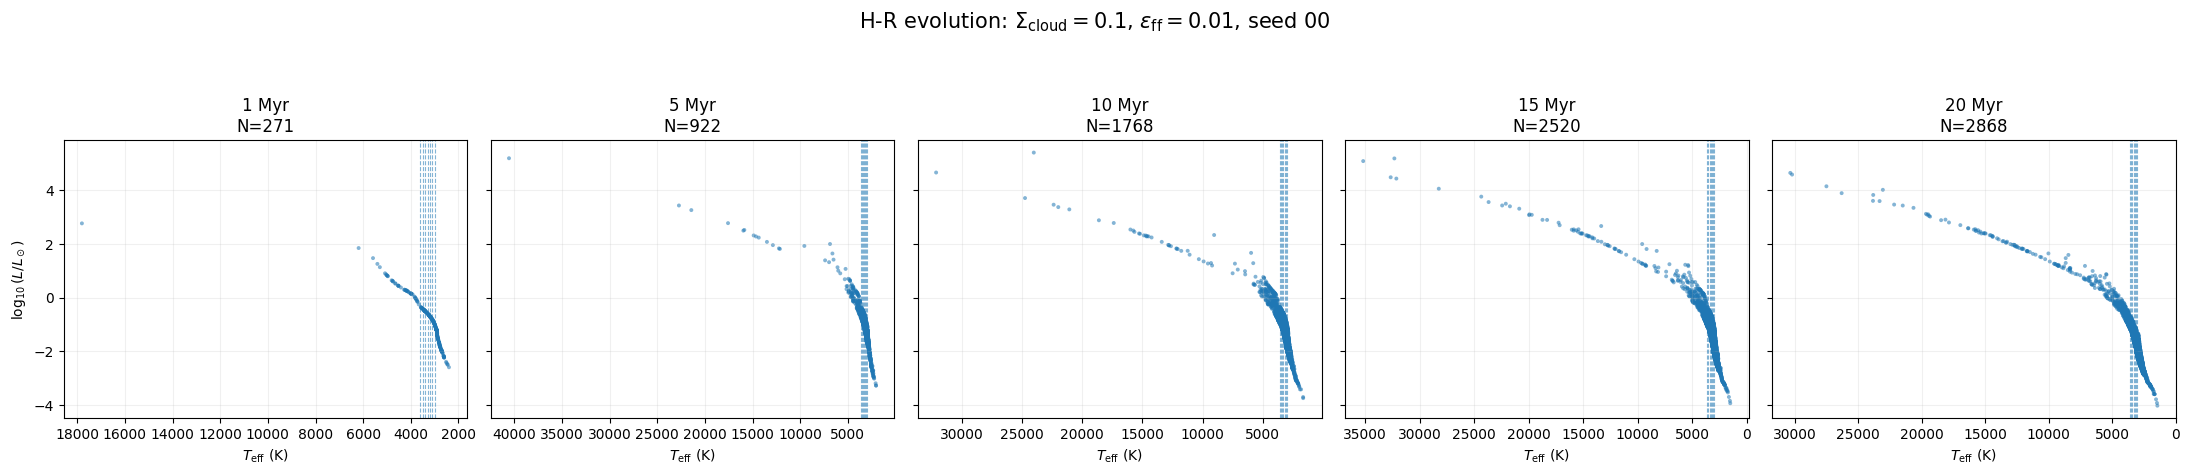

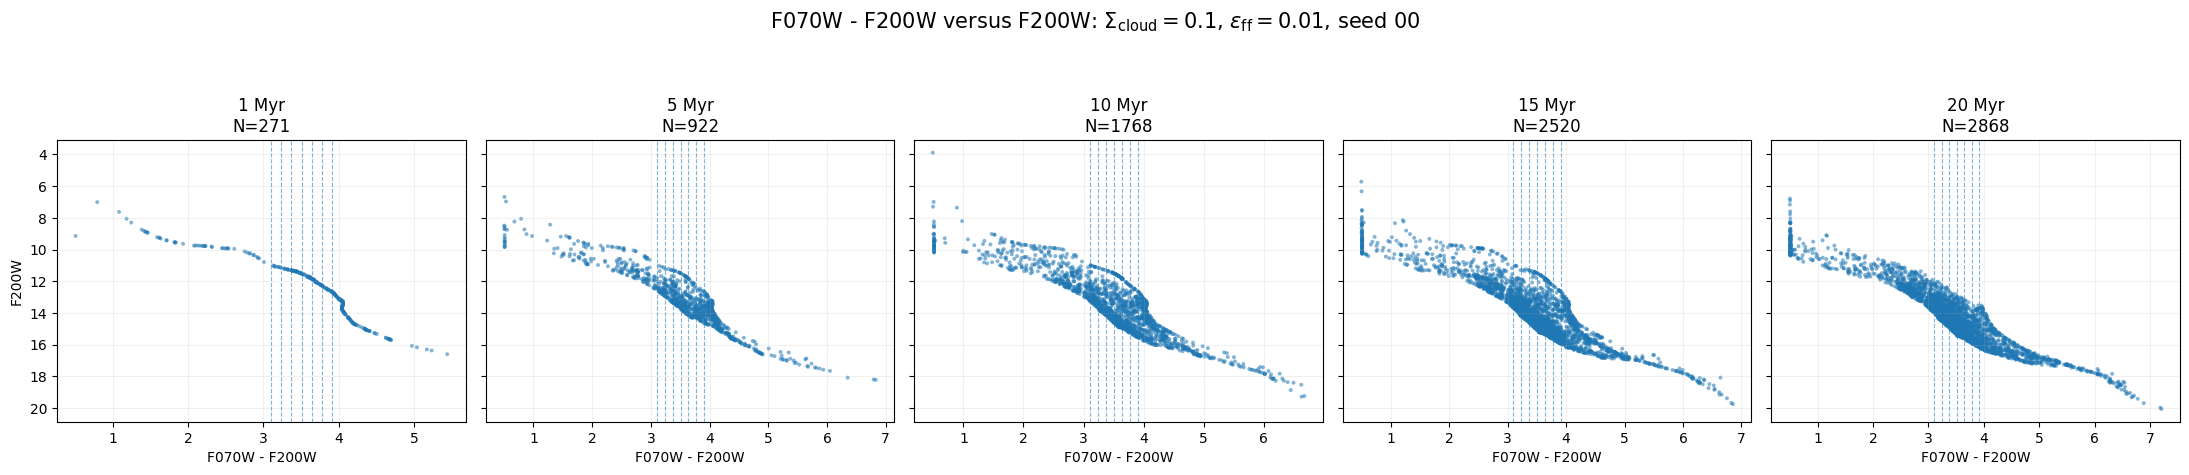


Generating evolution figures for sigma0p1_eff0p03_seed00


sigma0p1_eff0p03_seed00, t= 1.0 Myr: retained 534/543 primary systems
  interpolation accounting: young/clipped=437, older-than-grid=0, failed=9, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p03_seed00, t= 5.0 Myr: retained 2303/2329 primary systems
  interpolation accounting: young/clipped=397, older-than-grid=0, failed=26, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p03_seed00, t=10.0 Myr: retained 2881/2917 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=36, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p03_seed00, t=15.0 Myr: retained 2896/2934 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=38, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p03_seed00, t=20.0 Myr: retained 2791/2940 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=110, failed=39, bad mass=0, bad age=0, nonpositive L=0


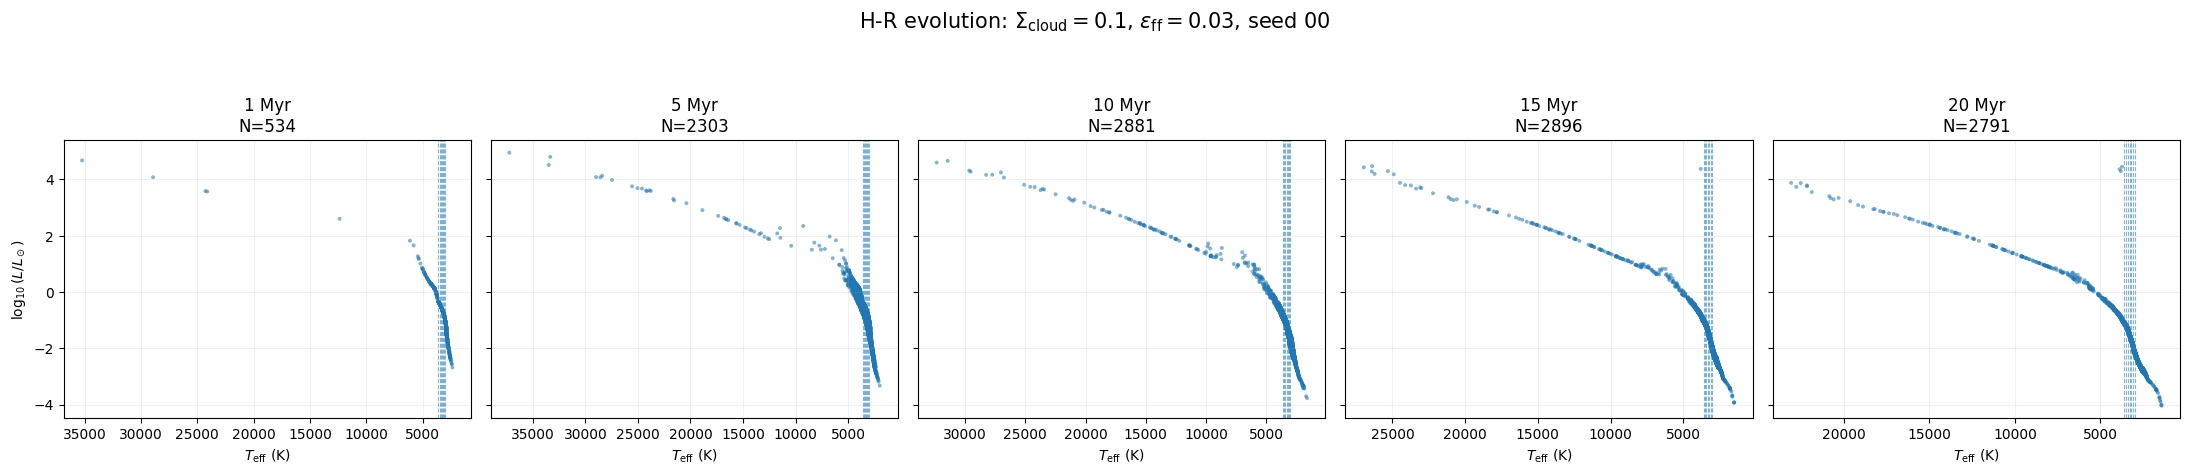

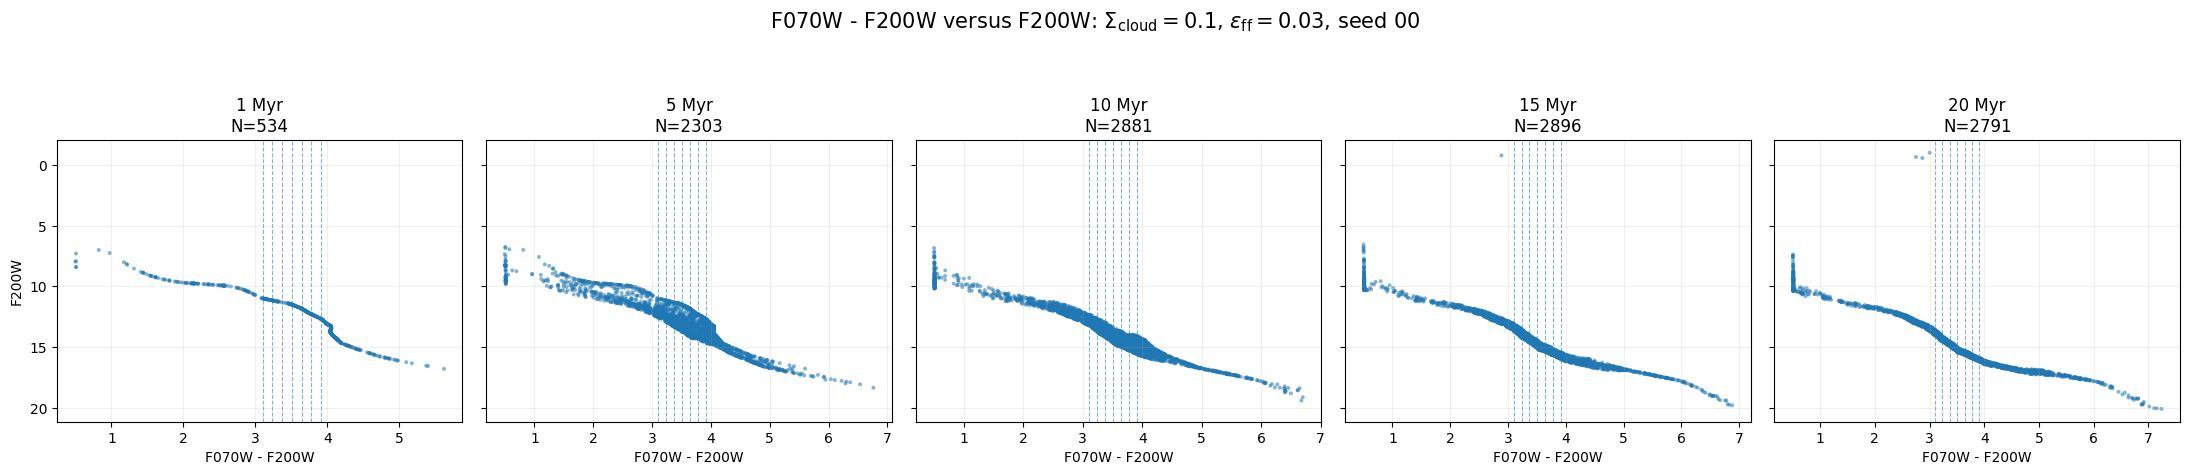


Generating evolution figures for sigma0p1_eff0p10_seed00


sigma0p1_eff0p10_seed00, t= 1.0 Myr: retained 1267/1275 primary systems
  interpolation accounting: young/clipped=1152, older-than-grid=0, failed=8, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p10_seed00, t= 5.0 Myr: retained 2557/2587 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=30, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p10_seed00, t=10.0 Myr: retained 2569/2604 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=35, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p10_seed00, t=15.0 Myr: retained 2569/2606 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=37, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p10_seed00, t=20.0 Myr: retained 2453/2611 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=116, failed=42, bad mass=0, bad age=0, nonpositive L=0


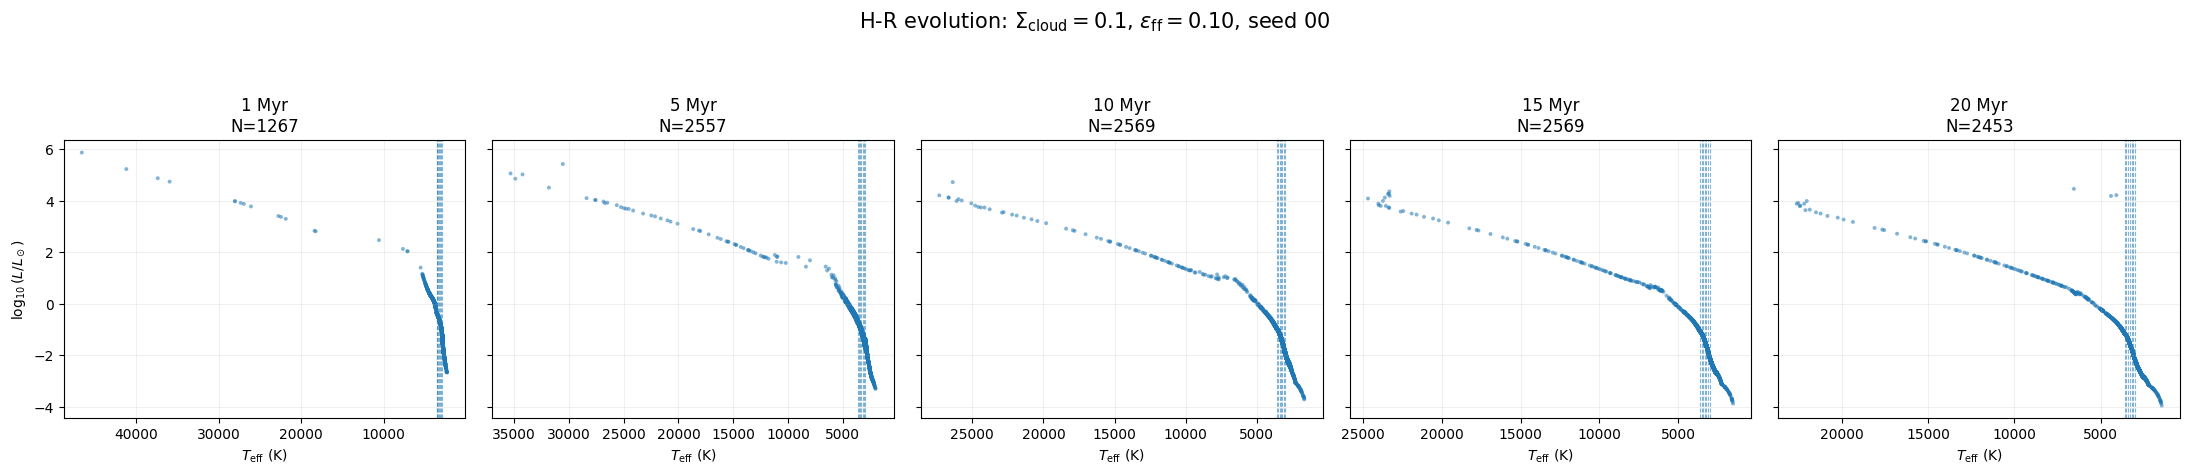

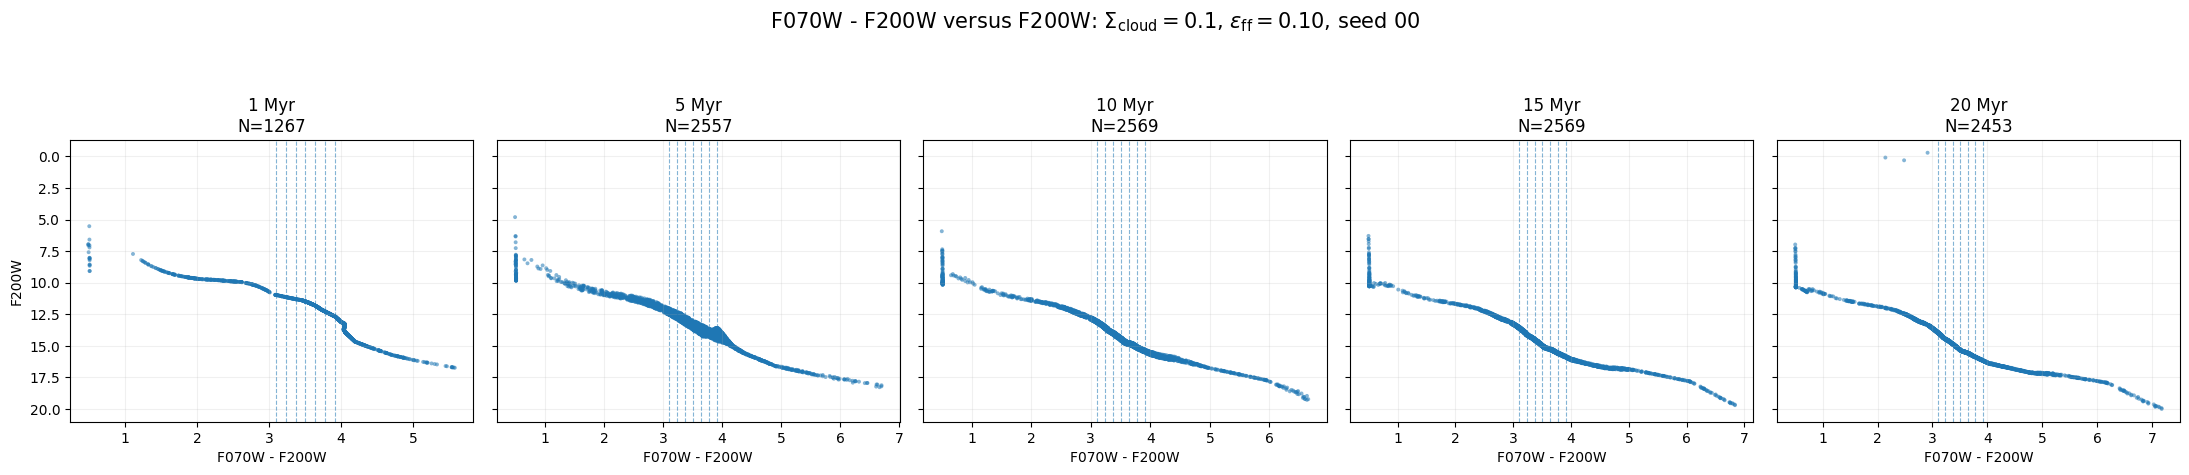


Generating evolution figures for sigma0p1_eff0p30_seed00


sigma0p1_eff0p30_seed00, t= 1.0 Myr: retained 2480/2509 primary systems
  interpolation accounting: young/clipped=2344, older-than-grid=0, failed=29, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p30_seed00, t= 5.0 Myr: retained 2509/2540 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=31, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p30_seed00, t=10.0 Myr: retained 2512/2546 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=34, bad mass=0, bad age=0, nonpositive L=0


/home/wyz5rge/TurbulentClusterModel/nbody62spisea/converter.py:236: RuntimeWarning: divide by zero encountered in log10
  log_a = numpy.concatenate( [numpy.full(len(singles),numpy.nan), numpy.log10(bdict['semi']) ] )


sigma0p1_eff0p30_seed00, t=15.0 Myr: retained 2508/2545 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=37, bad mass=0, bad age=0, nonpositive L=0


/home/wyz5rge/TurbulentClusterModel/nbody62spisea/converter.py:236: RuntimeWarning: divide by zero encountered in log10
  log_a = numpy.concatenate( [numpy.full(len(singles),numpy.nan), numpy.log10(bdict['semi']) ] )


sigma0p1_eff0p30_seed00, t=20.0 Myr: retained 2380/2548 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=132, failed=36, bad mass=0, bad age=0, nonpositive L=0


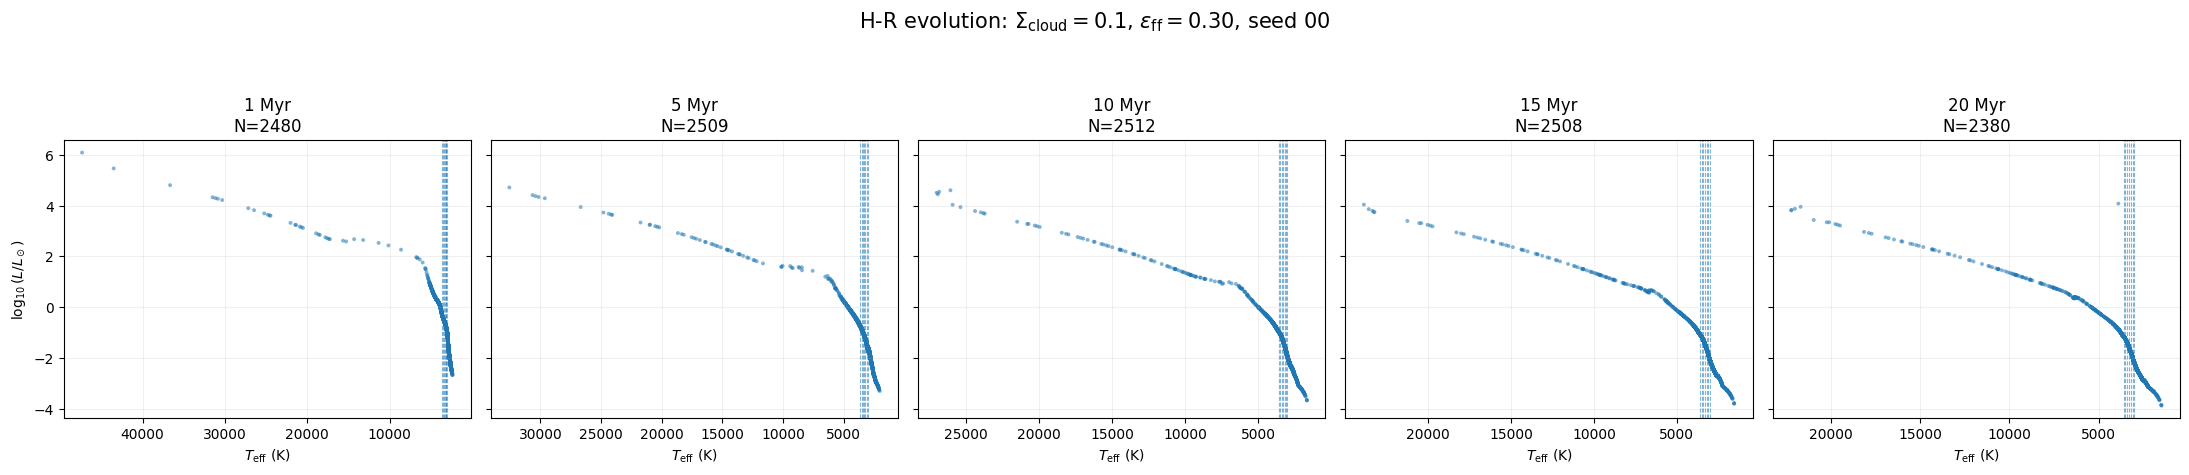

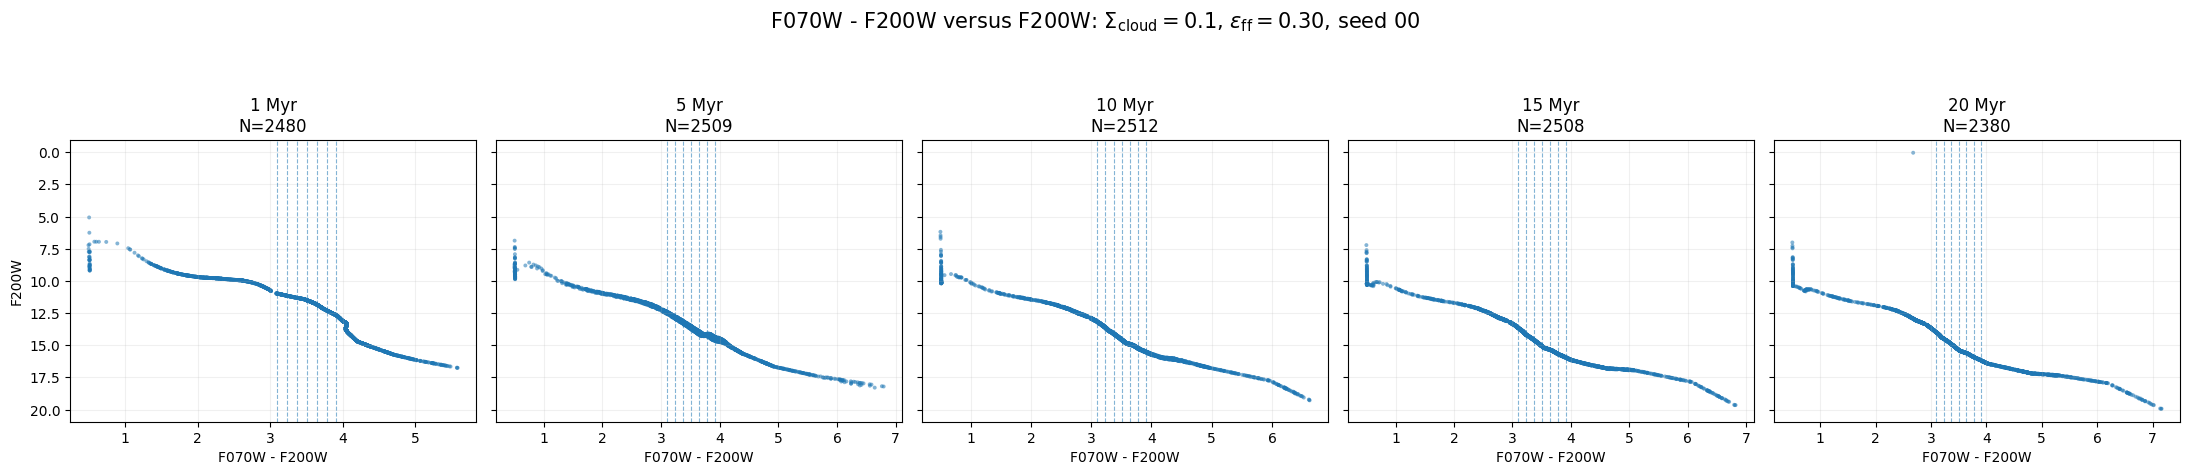


Generating evolution figures for sigma0p1_eff1p00_seed00


sigma0p1_eff1p00_seed00, t= 1.0 Myr: retained 2374/2404 primary systems
  interpolation accounting: young/clipped=2201, older-than-grid=0, failed=30, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff1p00_seed00, t= 5.0 Myr: retained 2395/2429 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=34, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff1p00_seed00, t=10.0 Myr: retained 2397/2430 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=33, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff1p00_seed00, t=15.0 Myr: retained 2396/2435 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=39, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff1p00_seed00, t=20.0 Myr: retained 2194/2440 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=204, failed=42, bad mass=0, bad age=0, nonpositive L=0


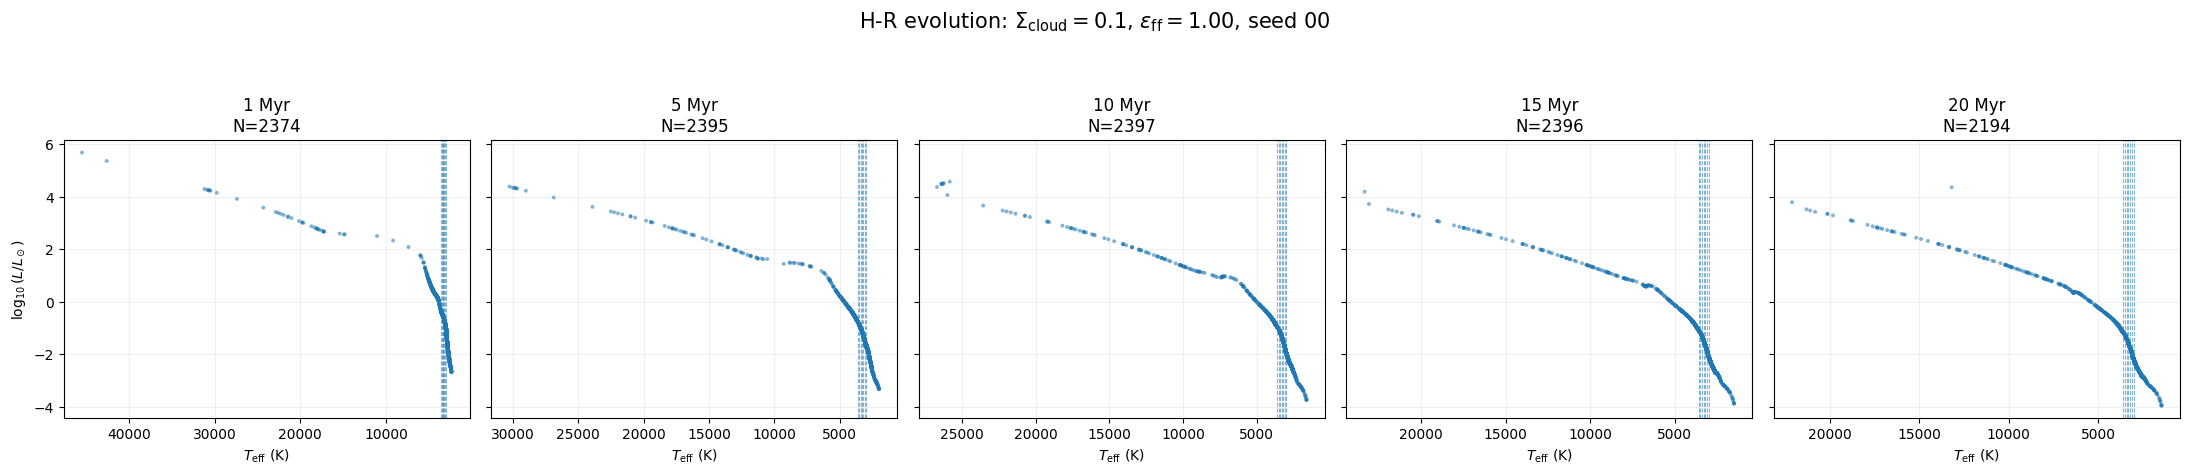

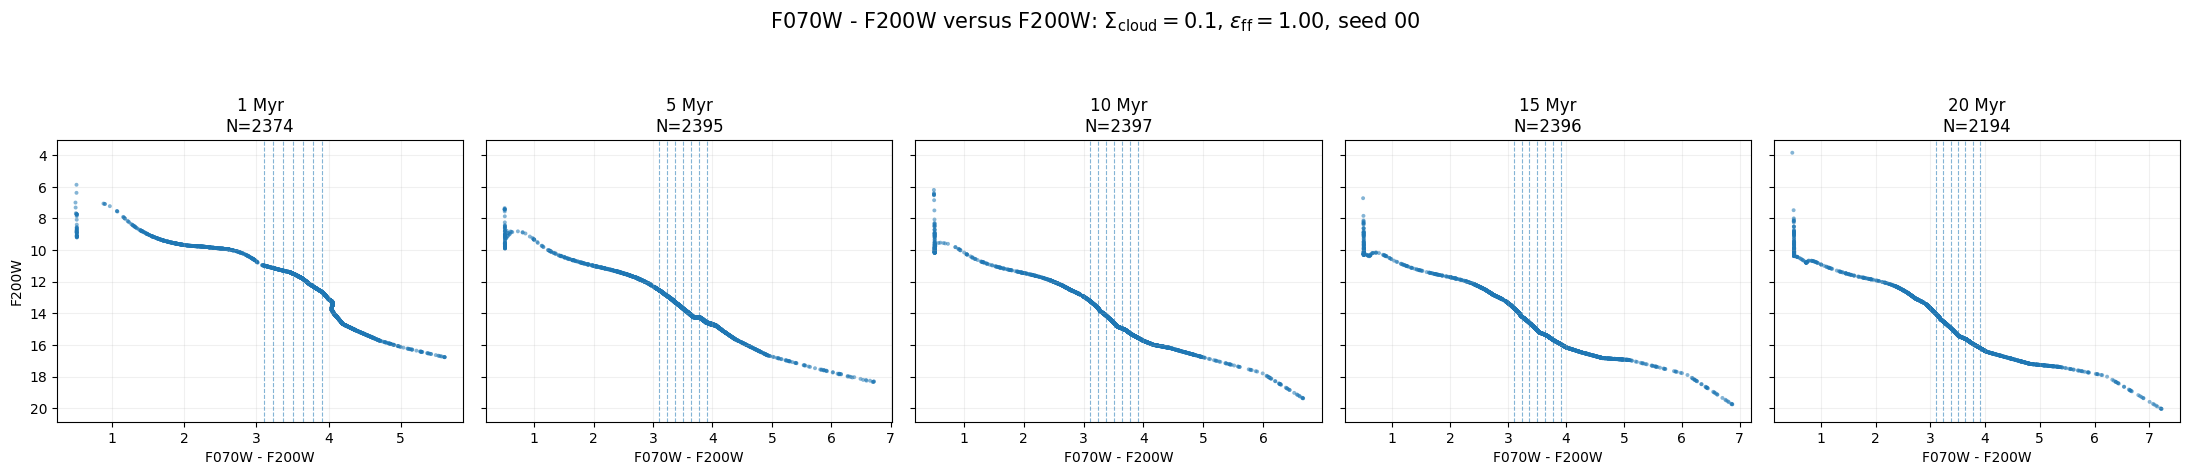


Generating evolution figures for sigma1p0_eff0p01_seed00


sigma1p0_eff0p01_seed00, t= 1.0 Myr: retained 786/803 primary systems
  interpolation accounting: young/clipped=687, older-than-grid=0, failed=17, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p01_seed00, t= 5.0 Myr: retained 2346/2386 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=40, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p01_seed00, t=10.0 Myr: retained 2342/2389 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=47, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p01_seed00, t=15.0 Myr: retained 2339/2391 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=52, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p01_seed00, t=20.0 Myr: retained 2340/2393 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=53, bad mass=0, bad age=0, nonpositive L=0


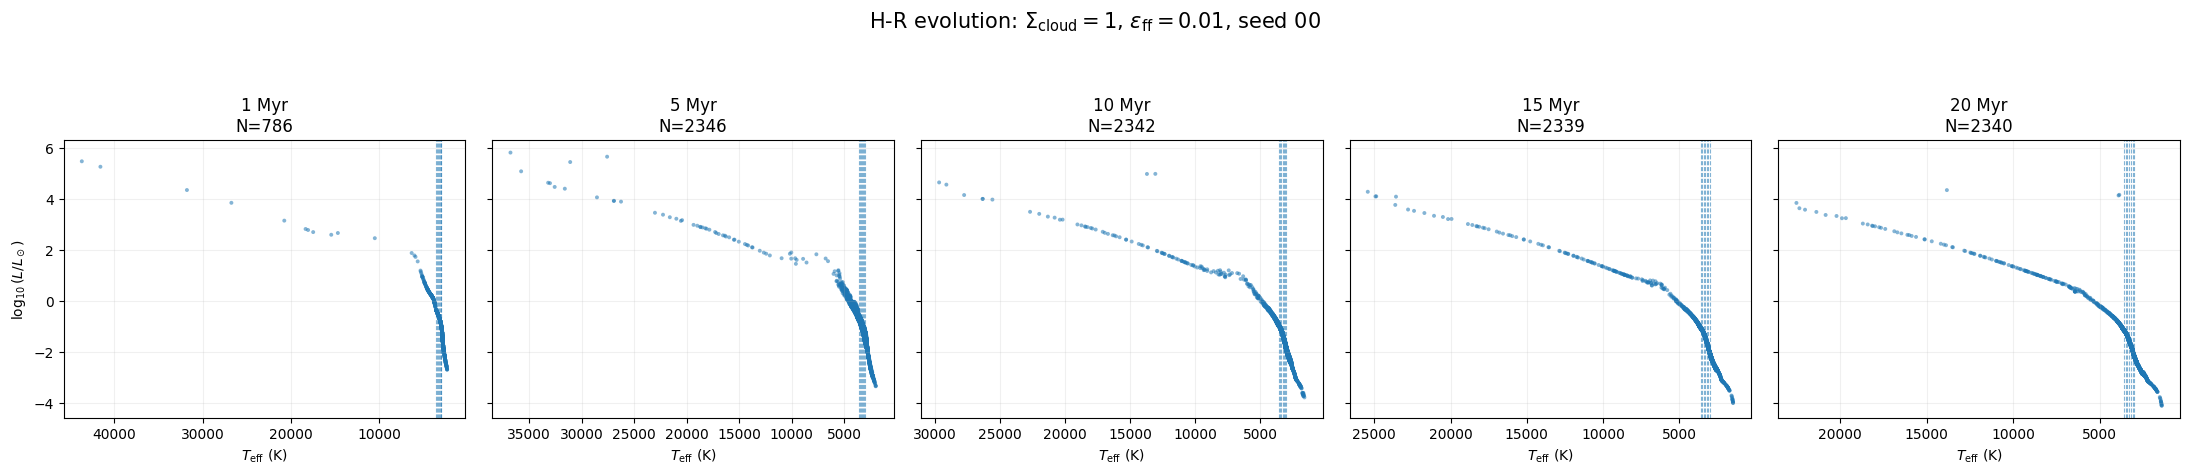

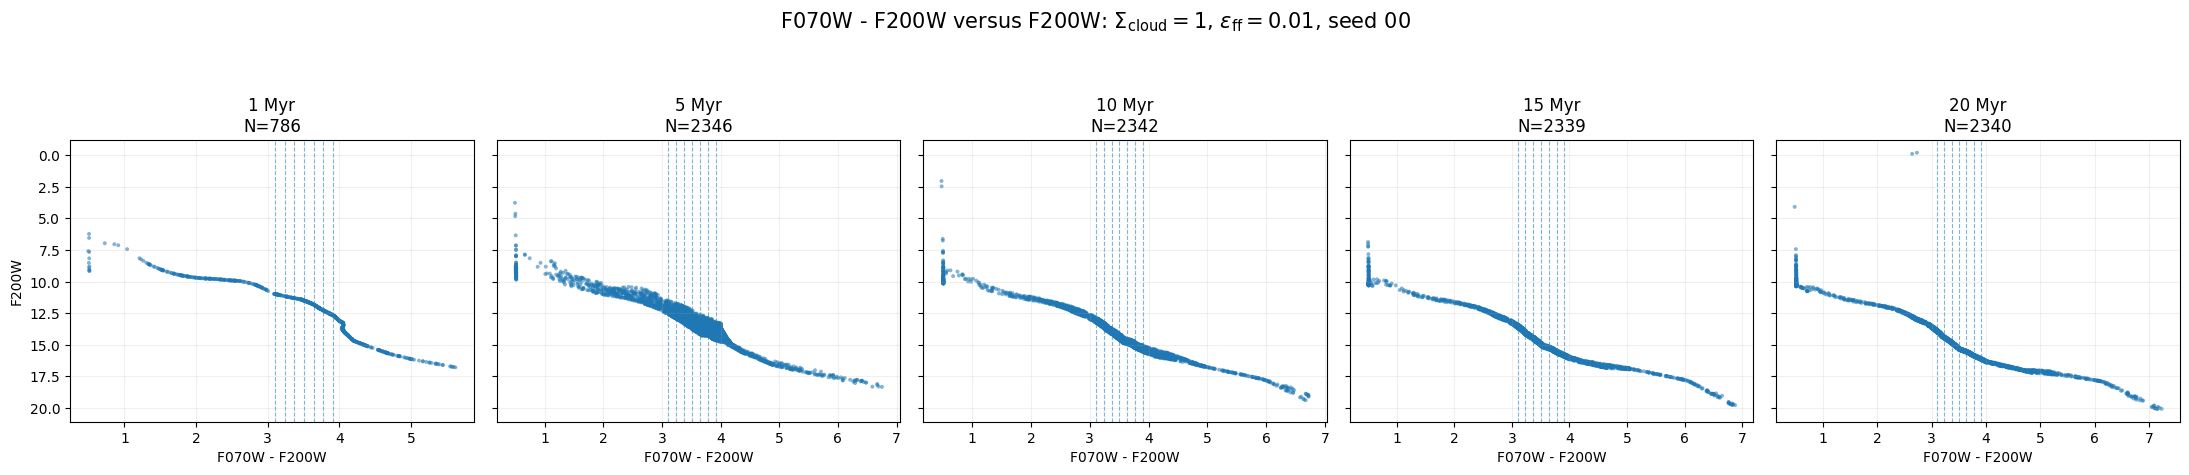


Generating evolution figures for sigma1p0_eff0p03_seed00


sigma1p0_eff0p03_seed00, t= 1.0 Myr: retained 2436/2459 primary systems
  interpolation accounting: young/clipped=2459, older-than-grid=0, failed=23, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p03_seed00, t= 5.0 Myr: retained 2792/2818 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=26, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p03_seed00, t=10.0 Myr: retained 2797/2827 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=30, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p03_seed00, t=15.0 Myr: retained 2799/2831 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=32, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p03_seed00, t=20.0 Myr: retained 2660/2834 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=143, failed=31, bad mass=0, bad age=0, nonpositive L=0


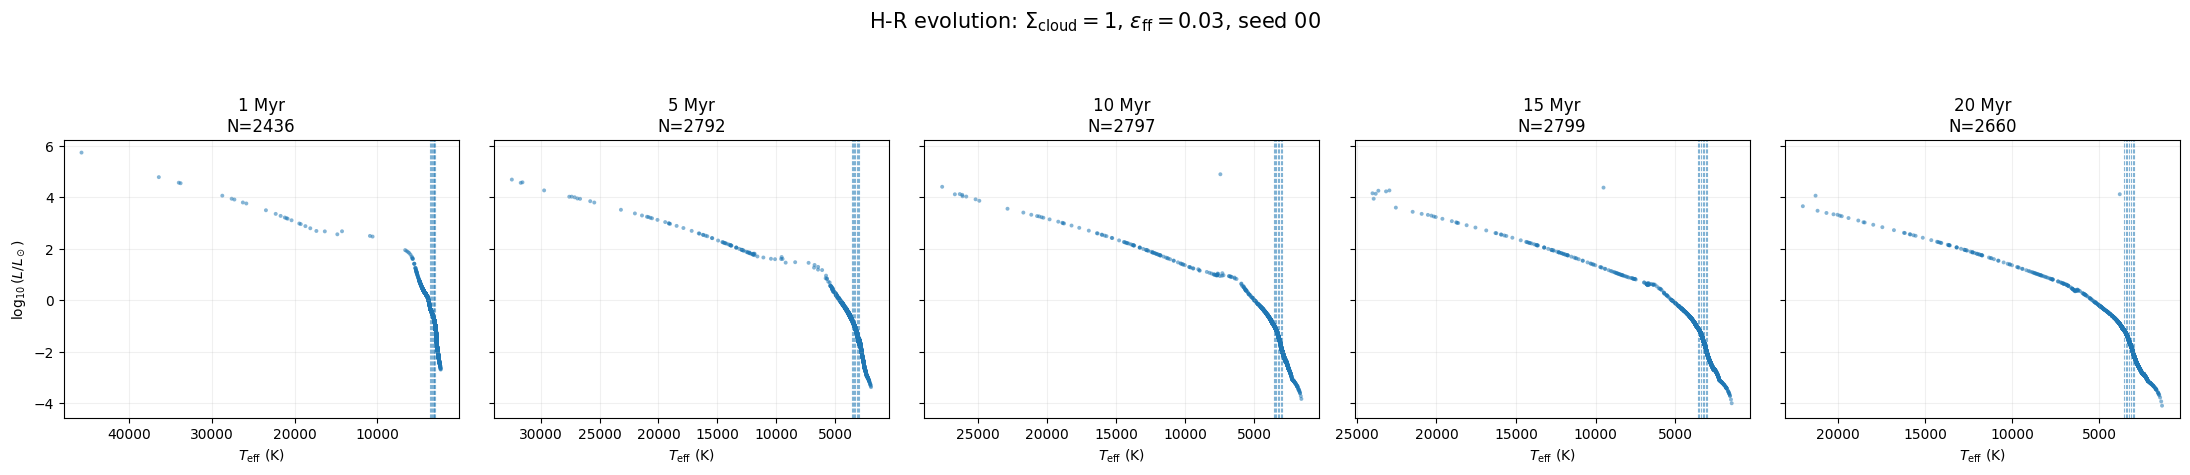

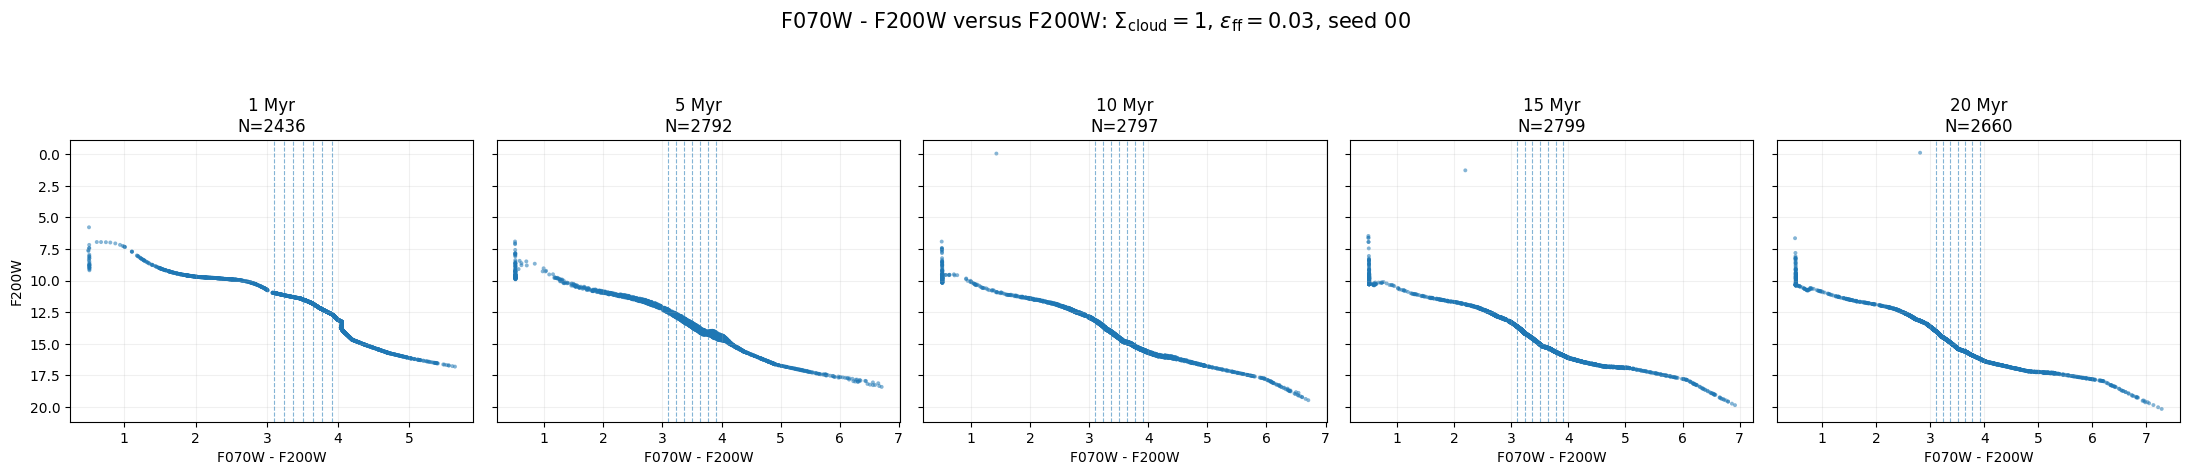


Generating evolution figures for sigma1p0_eff0p10_seed00


sigma1p0_eff0p10_seed00, t= 1.0 Myr: retained 2425/2453 primary systems
  interpolation accounting: young/clipped=2453, older-than-grid=0, failed=28, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p10_seed00, t= 5.0 Myr: retained 2438/2470 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=32, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p10_seed00, t=10.0 Myr: retained 2433/2465 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=32, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p10_seed00, t=15.0 Myr: retained 2433/2471 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=38, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p10_seed00, t=20.0 Myr: retained 2432/2473 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=41, bad mass=0, bad age=0, nonpositive L=0


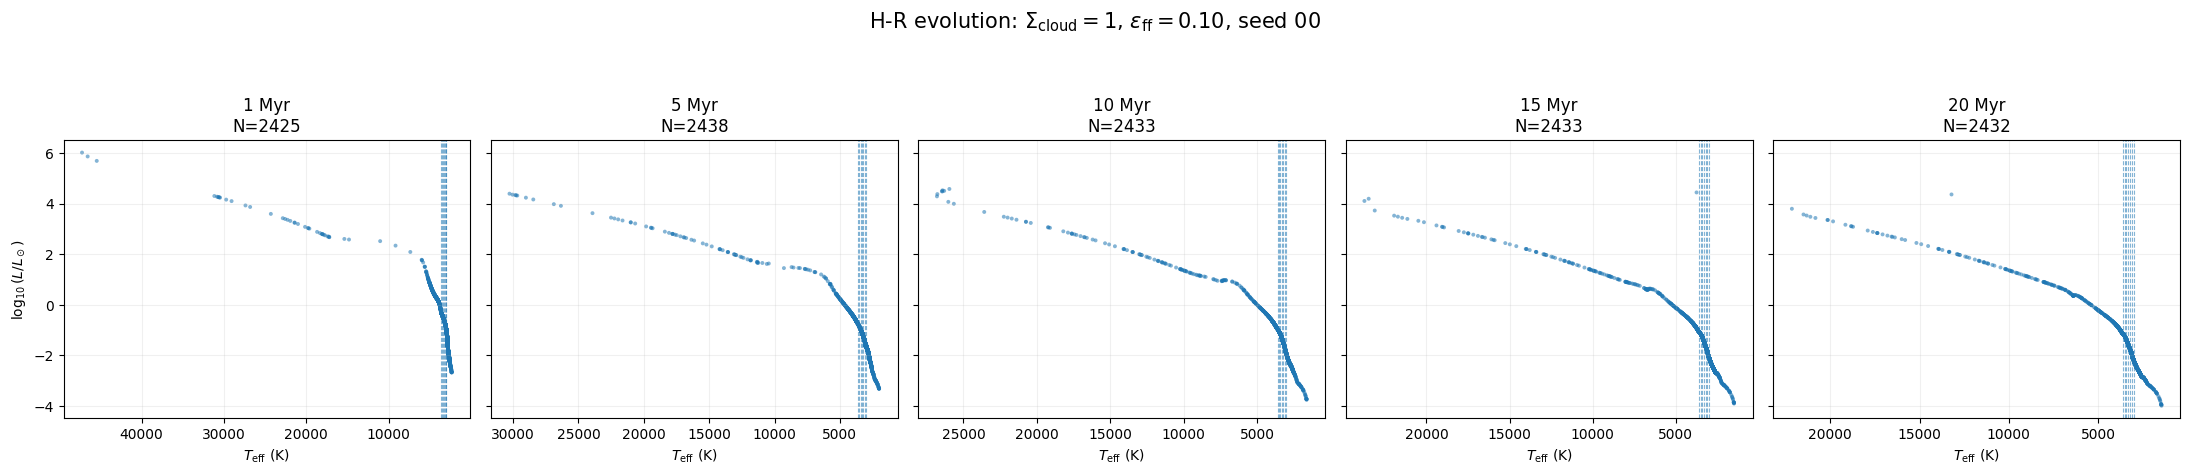

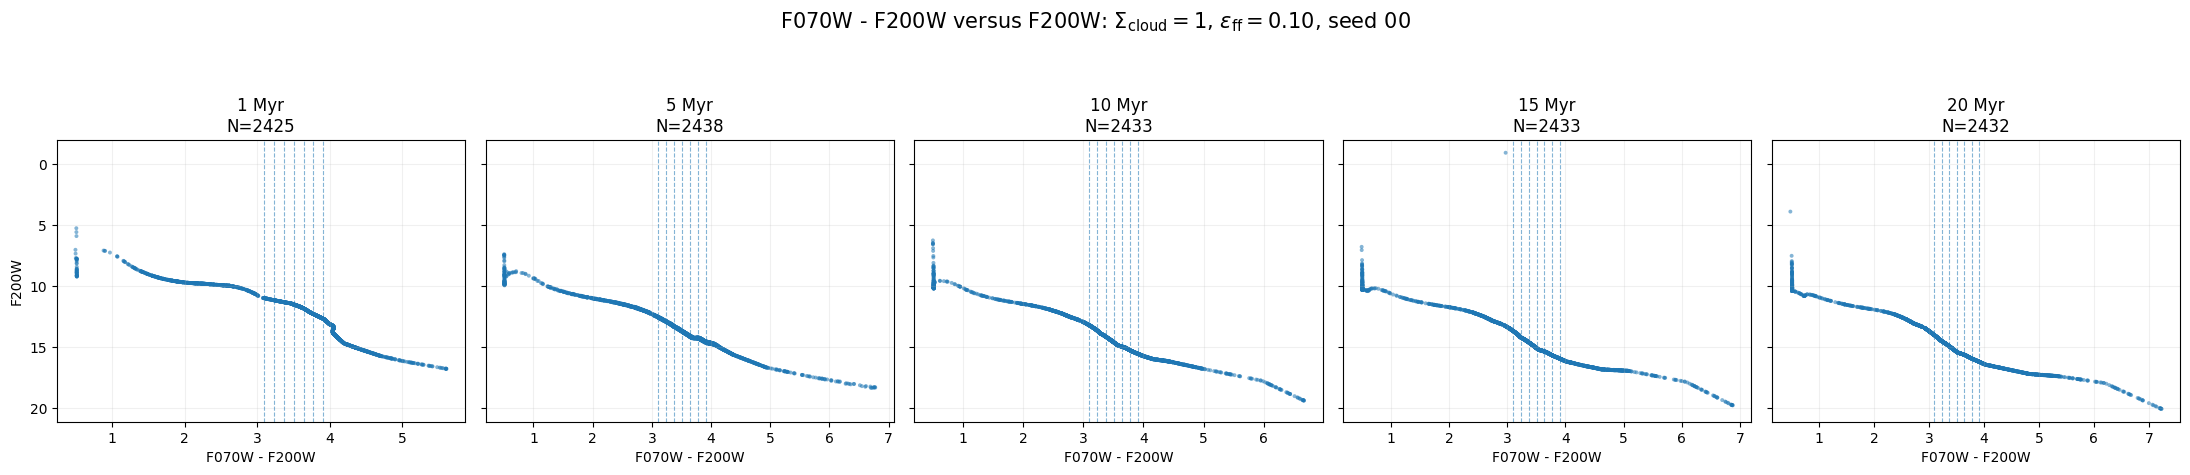


Generating evolution figures for sigma1p0_eff0p30_seed00


sigma1p0_eff0p30_seed00, t= 1.0 Myr: retained 2429/2458 primary systems
  interpolation accounting: young/clipped=2095, older-than-grid=0, failed=29, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p30_seed00, t= 5.0 Myr: retained 2440/2472 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=32, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p30_seed00, t=10.0 Myr: retained 2440/2472 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=32, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p30_seed00, t=15.0 Myr: retained 2432/2470 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=38, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff0p30_seed00, t=20.0 Myr: retained 2436/2477 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=41, bad mass=0, bad age=0, nonpositive L=0


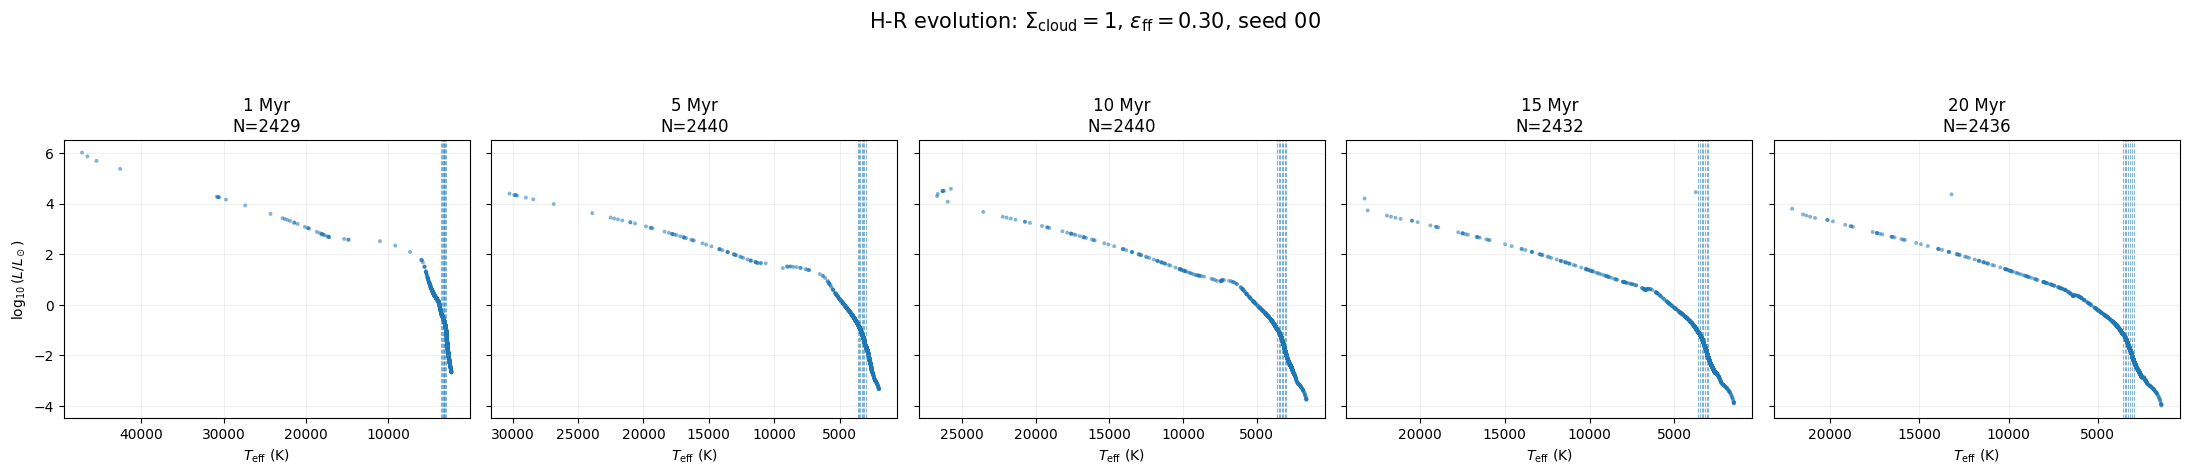

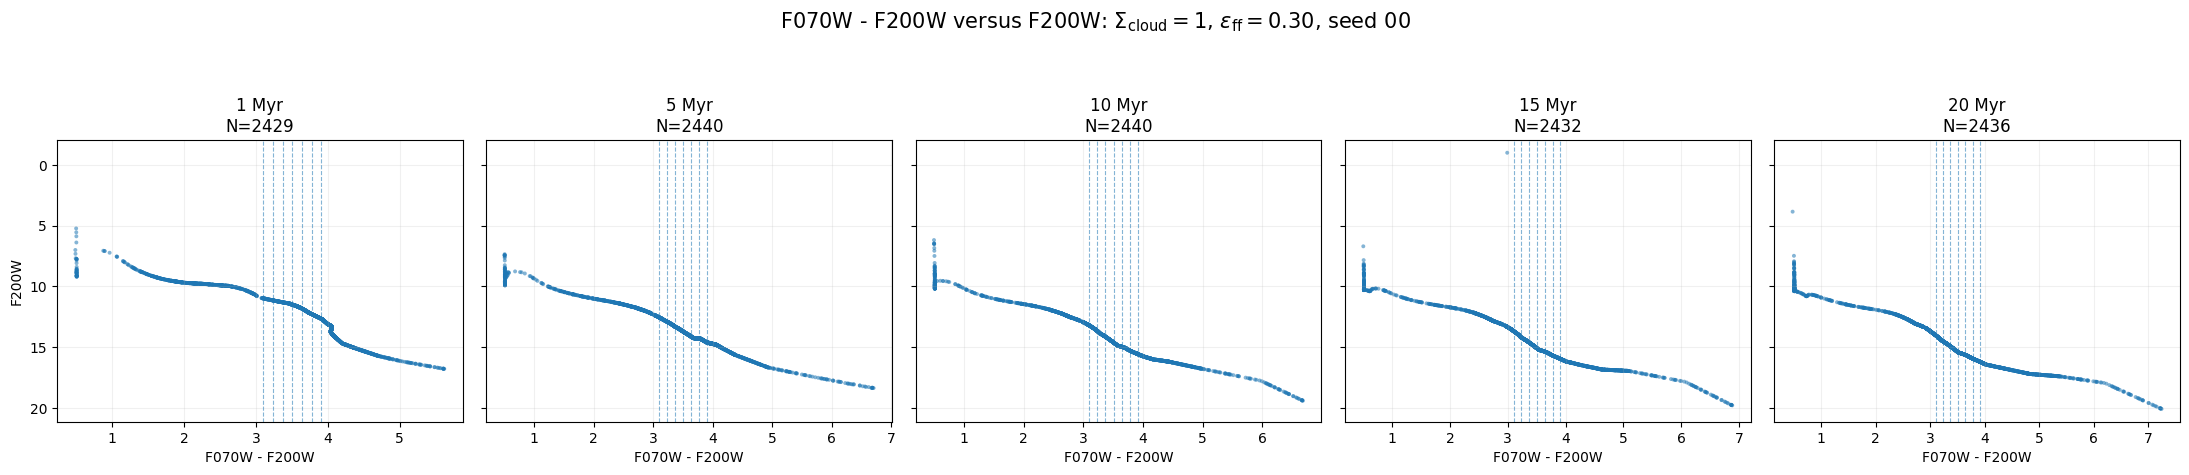


Generating evolution figures for sigma1p0_eff1p00_seed00


sigma1p0_eff1p00_seed00, t= 1.0 Myr: retained 2442/2469 primary systems
  interpolation accounting: young/clipped=1170, older-than-grid=0, failed=27, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff1p00_seed00, t= 5.0 Myr: retained 2457/2489 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=32, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff1p00_seed00, t=10.0 Myr: retained 2454/2485 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=31, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff1p00_seed00, t=15.0 Myr: retained 2450/2488 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=38, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff1p00_seed00, t=20.0 Myr: retained 2448/2488 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=40, bad mass=0, bad age=0, nonpositive L=0


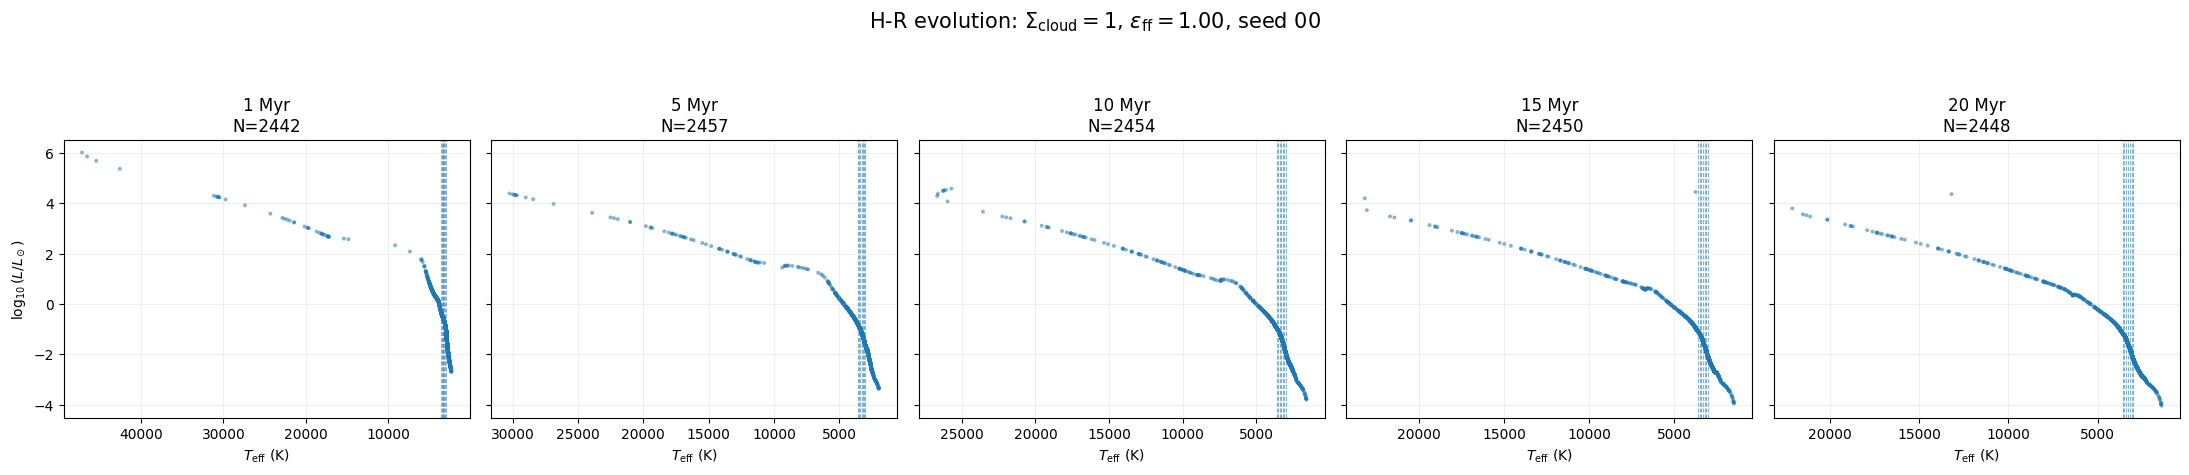

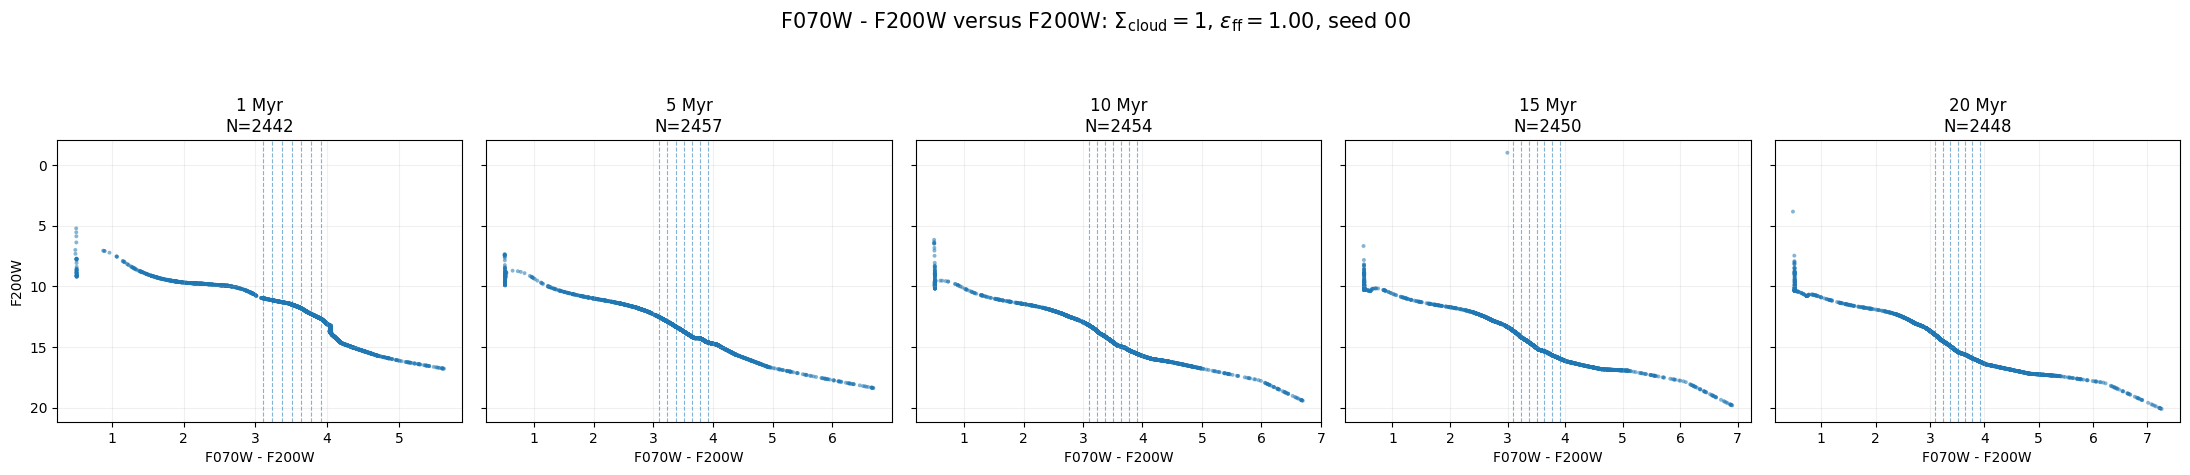

In [12]:
for simulation in SIMULATIONS:
    print(
        "\nGenerating evolution figures for "
        f"{simulation.file_tag}"
    )

    evolution_snapshots = collect_evolution_snapshots(
        simulation,
        ISO_GRID,
    )

    plot_hr_evolution(
        simulation,
        evolution_snapshots,
    )
    plot_cmd_evolution(
        simulation,
        evolution_snapshots,
    )

## Quartile spread metric

In [13]:
def quartile_spread_metric(
    horizontal: np.ndarray,
    vertical: np.ndarray,
    bin_edges: np.ndarray,
    vertical_mode: str,
    min_stars_per_bin: int = MIN_STARS_PER_BIN,
    quartile_fraction: float = QUARTILE_FRACTION,
) -> SpreadResult:
    horizontal = np.asarray(
        horizontal,
        dtype=float,
    )
    vertical = np.asarray(
        vertical,
        dtype=float,
    )

    good = (
        np.isfinite(horizontal)
        & np.isfinite(vertical)
    )

    horizontal = horizontal[good]
    vertical = vertical[good]

    bin_spreads = np.full(
        len(bin_edges) - 1,
        np.nan,
    )
    bin_counts = np.zeros(
        len(bin_edges) - 1,
        dtype=int,
    )

    in_full_band = (
        (horizontal >= bin_edges[0])
        & (horizontal <= bin_edges[-1])
    )
    n_stars_in_band = int(
        np.sum(in_full_band)
    )

    for bin_index in range(
        len(bin_edges) - 1
    ):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == len(bin_edges) - 2:
            in_bin = (
                (horizontal >= lower)
                & (horizontal <= upper)
            )
        else:
            in_bin = (
                (horizontal >= lower)
                & (horizontal < upper)
            )

        values = np.sort(
            vertical[in_bin]
        )
        n_stars = len(values)
        bin_counts[bin_index] = n_stars

        if n_stars < min_stars_per_bin:
            continue

        n_quartile = max(
            1,
            int(
                np.floor(
                    quartile_fraction * n_stars
                )
            ),
        )

        low_values = values[:n_quartile]
        high_values = values[-n_quartile:]

        if vertical_mode == "luminosity":
            spread = (
                np.mean(high_values)
                - np.mean(low_values)
            )
        elif vertical_mode == "magnitude":
            spread = (
                np.mean(high_values)
                - np.mean(low_values)
            )
        else:
            raise ValueError(
                "vertical_mode must be 'luminosity' or 'magnitude'."
            )

        bin_spreads[bin_index] = float(
            spread
        )

    valid = np.isfinite(
        bin_spreads
    )

    metric = (
        float(
            np.nanmean(bin_spreads)
        )
        if np.any(valid)
        else np.nan
    )

    return SpreadResult(
        metric=metric,
        bin_spreads=bin_spreads,
        bin_counts=bin_counts,
        n_valid_bins=int(
            np.sum(valid)
        ),
        n_stars_in_band=n_stars_in_band,
    )


def measure_snapshot_spaces(
    df: pd.DataFrame,
) -> dict[str, SpreadResult]:
    if df.empty:
        raise ValueError(
            "measure_snapshot_spaces() received an empty stellar table."
        )

    required_columns = {
        "teff",
        "log_luminosity_lsun",
        "color_F070W_F200W",
        "mag_F200W",
    }
    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise KeyError(
            "Interpolated stellar table is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    return {
        "H-R": quartile_spread_metric(
            df["teff"].to_numpy(),
            df["log_luminosity_lsun"].to_numpy(),
            TEFF_BIN_EDGES_K,
            vertical_mode="luminosity",
        ),
        CMD_NAME: quartile_spread_metric(
            df["color_F070W_F200W"].to_numpy(),
            df["mag_F200W"].to_numpy(),
            CMD_BIN_EDGES,
            vertical_mode="magnitude",
        ),
    }

## Run the complete time-series analysis

In [14]:
def run_all_spread_time_series(
    configs: Sequence[SimulationConfig],
    times_myr: Iterable[float],
    grid: IsochroneGrid,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    summary_rows = []
    bin_rows = []
    snapshot_rows = []

    for sim in configs:
        print(
            "\n========================================"
        )
        print(
            f"Analyzing {sim.file_tag}"
        )
        print(
            "========================================"
        )

        for time_myr in times_myr:
            df = load_and_interpolate_snapshot(
                sim,
                float(time_myr),
                grid,
            )

            if df is None or df.empty:
                snapshot_rows.append(
                    {
                        "density": sim.density,
                        "epsilon_ff": sim.epsilon_ff,
                        "seed": sim.seed,
                        "time_myr": float(time_myr),
                        "snapshot_available": df is not None,
                        "n_interpolated_stars": 0,
                    }
                )

                print(
                    f"  No usable interpolated stars for "
                    f"{sim.file_tag} at {float(time_myr):.1f} Myr; "
                    "recording the snapshot and continuing."
                )
                continue

            snapshot_rows.append(
                {
                    "density": sim.density,
                    "epsilon_ff": sim.epsilon_ff,
                    "seed": sim.seed,
                    "time_myr": float(time_myr),
                    "snapshot_available": True,
                    "n_interpolated_stars": len(df),
                }
            )

            measurements = measure_snapshot_spaces(
                df
            )

            for space_name, result in measurements.items():
                summary_rows.append(
                    {
                        "density": sim.density,
                        "epsilon_ff": sim.epsilon_ff,
                        "seed": sim.seed,
                        "time_myr": float(time_myr),
                        "space": space_name,
                        "spread_metric": result.metric,
                        "n_valid_bins": result.n_valid_bins,
                        "n_stars_in_band": result.n_stars_in_band,
                        "n_interpolated_stars": len(df),
                    }
                )

                for bin_index, (
                    spread,
                    count,
                ) in enumerate(
                    zip(
                        result.bin_spreads,
                        result.bin_counts,
                    ),
                    start=1,
                ):
                    bin_rows.append(
                        {
                            "density": sim.density,
                            "epsilon_ff": sim.epsilon_ff,
                            "seed": sim.seed,
                            "time_myr": float(time_myr),
                            "space": space_name,
                            "bin": bin_index,
                            "bin_spread": spread,
                            "bin_count": int(count),
                        }
                    )

    summary_columns = [
        "density",
        "epsilon_ff",
        "seed",
        "time_myr",
        "space",
        "spread_metric",
        "n_valid_bins",
        "n_stars_in_band",
        "n_interpolated_stars",
    ]
    bin_columns = [
        "density",
        "epsilon_ff",
        "seed",
        "time_myr",
        "space",
        "bin",
        "bin_spread",
        "bin_count",
    ]
    snapshot_columns = [
        "density",
        "epsilon_ff",
        "seed",
        "time_myr",
        "snapshot_available",
        "n_interpolated_stars",
    ]

    return (
        pd.DataFrame(summary_rows, columns=summary_columns),
        pd.DataFrame(bin_rows, columns=bin_columns),
        pd.DataFrame(snapshot_rows, columns=snapshot_columns),
    )

In [15]:
(
    df_spread_summary,
    df_spread_bins,
    df_snapshot_availability,
) = run_all_spread_time_series(
    SIMULATIONS,
    ANALYSIS_TIMES_MYR,
    ISO_GRID,
)

display(df_spread_summary.head(20))
display(df_spread_bins.head(20))
display(df_snapshot_availability.head(20))

if df_spread_summary.empty:
    missing_paths = PATH_VALIDATION.loc[
        ~PATH_VALIDATION["exists"],
        ["density", "epsilon_ff", "path"],
    ]

    raise RuntimeError(
        "No spread measurements were produced. The most likely cause is "
        "that the simulation paths are incorrect or no requested snapshots "
        "could be read.\n\nConfigured missing paths:\n"
        + (
            missing_paths.to_string(index=False)
            if len(missing_paths) > 0
            else "None; inspect the snapshot-reading messages above."
        )
    )

df_spread_summary.to_csv(
    OUTPUT_DIR / "spread_metric_time_series.csv",
    index=False,
)

df_spread_bins.to_csv(
    OUTPUT_DIR / "spread_metric_by_bin.csv",
    index=False,
)

df_snapshot_availability.to_csv(
    OUTPUT_DIR / "snapshot_availability.csv",
    index=False,
)


Analyzing sigma0p1_eff0p01_seed00


sigma0p1_eff0p01_seed00, t= 1.0 Myr: retained 271/273 primary systems
  interpolation accounting: young/clipped=166, older-than-grid=0, failed=2, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p01_seed00, t= 1.5 Myr: retained 386/389 primary systems
  interpolation accounting: young/clipped=194, older-than-grid=0, failed=3, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p01_seed00, t= 2.0 Myr: retained 461/465 primary systems
  interpolation accounting: young/clipped=192, older-than-grid=0, failed=4, bad mass=0, bad age=0, nonpositive L=0


sigma0p1_eff0p01_seed00, t= 2.5 Myr: retained 565/570 primary systems
  interpolation accounting: young/clipped=193, older-than-grid=0, failed=5, bad mass=0, bad age=0, nonpositive L=0


...

sigma1p0_eff1p00_seed00, t=19.5 Myr: retained 2449/2489 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=40, bad mass=0, bad age=0, nonpositive L=0


sigma1p0_eff1p00_seed00, t=20.0 Myr: retained 2448/2488 primary systems
  interpolation accounting: young/clipped=0, older-than-grid=0, failed=40, bad mass=0, bad age=0, nonpositive L=0


,density,epsilon_ff,seed,time_myr,space,spread_metric,n_valid_bins,n_stars_in_band,n_interpolated_stars
0,0.1,0.01,00,1.0,H-R,0.079136,6,92,271
1,0.1,0.01,00,1.0,F070W-F200W,0.214575,6,92,271
2,0.1,0.01,00,1.5,H-R,0.197289,6,131,386
3,0.1,0.01,00,1.5,F070W-F200W,0.616758,6,135,386
4,0.1,0.01,00,2.0,H-R,0.280180,6,157,461
5,0.1,0.01,00,2.0,F070W-F200W,0.939618,6,163,461
6,0.1,0.01,00,2.5,H-R,0.337476,6,197,565
7,0.1,0.01,00,2.5,F070W-F200W,1.160719,6,207,565
8,0.1,0.01,00,3.0,H-R,0.401160,6,242,677
9,0.1,0.01,00,3.0,F070W-F200W,1.401061,6,259,677


,density,epsilon_ff,seed,time_myr,space,bin,bin_spread,bin_count
0,0.1,0.01,00,1.0,H-R,1,0.143437,20
1,0.1,0.01,00,1.0,H-R,2,0.100414,18
2,0.1,0.01,00,1.0,H-R,3,0.051221,15
3,0.1,0.01,00,1.0,H-R,4,0.070097,13
4,0.1,0.01,00,1.0,H-R,5,0.062270,18
5,0.1,0.01,00,1.0,H-R,6,0.047376,8
6,0.1,0.01,00,1.0,F070W-F200W,1,0.111500,8
7,0.1,0.01,00,1.0,F070W-F200W,2,0.100000,8
8,0.1,0.01,00,1.0,F070W-F200W,3,0.173250,19
9,0.1,0.01,00,1.0,F070W-F200W,4,0.232750,18


,density,epsilon_ff,seed,time_myr,snapshot_available,n_interpolated_stars
0,0.1,0.01,00,1.0,True,271
1,0.1,0.01,00,1.5,True,386
2,0.1,0.01,00,2.0,True,461
3,0.1,0.01,00,2.5,True,565
4,0.1,0.01,00,3.0,True,677
5,0.1,0.01,00,3.5,True,732
6,0.1,0.01,00,4.0,True,807
7,0.1,0.01,00,4.5,True,860
8,0.1,0.01,00,5.0,True,922
9,0.1,0.01,00,5.5,True,970


## Grouped spread-metric plots

One figure is produced for each diagram type. Within each figure:

- the left panel contains density 0.1;
- the right panel contains density 1.0;
- each line represents one epsilon_ff value.

In [16]:
def plot_grouped_spread_metric(
    df_summary: pd.DataFrame,
    space_name: str,
    ylabel: str,
    filename: str,
) -> None:
    densities = sorted(
        df_summary["density"].dropna().unique()
    )

    fig, axes = plt.subplots(
        1,
        len(densities),
        figsize=(13.5, 5.3),
        sharey=True,
        squeeze=False,
    )
    axes = axes.flatten()

    for ax, density in zip(
        axes,
        densities,
    ):
        density_data = df_summary[
            (df_summary["space"] == space_name)
            & (df_summary["density"] == density)
        ].copy()

        for epsilon_ff in sorted(
            density_data["epsilon_ff"].unique()
        ):
            curve = density_data[
                density_data["epsilon_ff"] == epsilon_ff
            ].sort_values(
                "time_myr"
            )

            ax.plot(
                curve["time_myr"],
                curve["spread_metric"],
                marker="o",
                markersize=3.5,
                linewidth=1.4,
                label=rf"$\epsilon_{{\rm ff}}={epsilon_ff:.2f}$",
            )

            incomplete = (
                curve["n_valid_bins"] < N_BINS
            )

            if np.any(incomplete):
                ax.scatter(
                    curve.loc[
                        incomplete,
                        "time_myr",
                    ],
                    curve.loc[
                        incomplete,
                        "spread_metric",
                    ],
                    marker="x",
                    s=35,
                    zorder=4,
                )

        ax.set_title(
            rf"$\Sigma_{{\rm cloud}}={density:g}$ "
            r"g cm$^{-2}$"
        )
        ax.set_xlabel(
            "Simulation time (Myr)"
        )
        ax.grid(alpha=0.25)
        ax.legend(
            fontsize=9,
        )

    axes[0].set_ylabel(
        ylabel
    )

    fig.suptitle(
        f"{space_name} spread metric evolution, seed {SEED}",
        fontsize=15,
    )
    fig.tight_layout(
        rect=(0, 0, 1, 0.93)
    )

    finish_figure(
        fig,
        filename,
    )

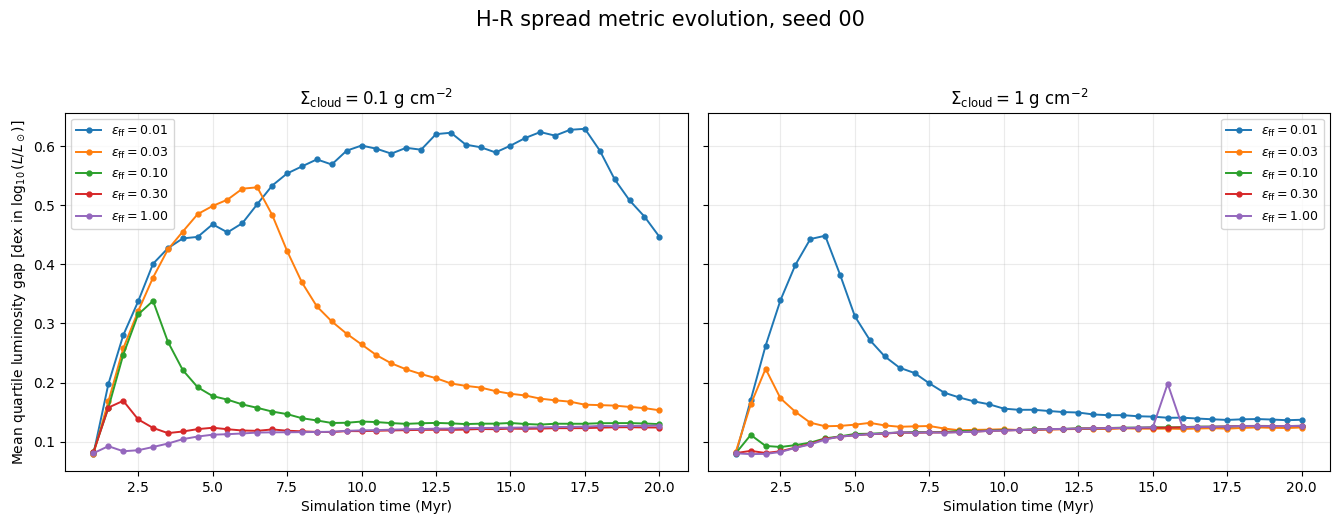

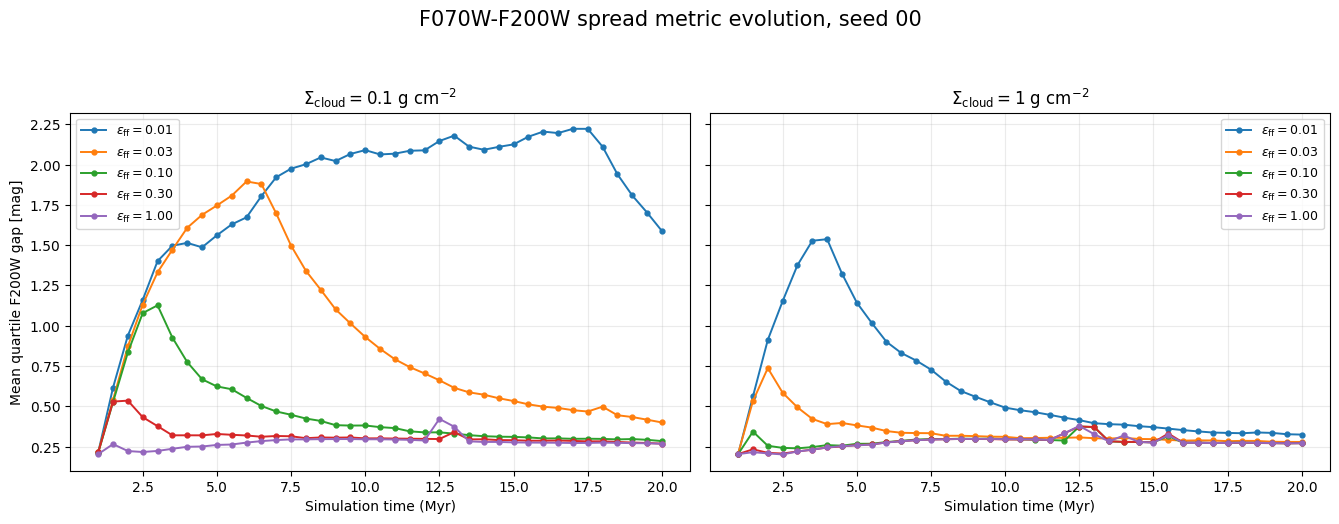

In [17]:
plot_grouped_spread_metric(
    df_spread_summary,
    "H-R",
    (
        "Mean quartile luminosity gap "
        r"[dex in $\log_{10}(L/L_\odot)$]"
    ),
    "grouped_hr_spread_metric.png",
)

plot_grouped_spread_metric(
    df_spread_summary,
    CMD_NAME,
    "Mean quartile F200W gap [mag]",
    "grouped_f070w_f200w_spread_metric.png",
)

## Optional grouped bin-occupancy diagnostics

These figures show whether apparent changes in the metric coincide with
bins becoming sparsely populated. One figure is generated for each diagram
type and density. Each panel corresponds to an epsilon_ff value.

In [18]:
def plot_grouped_bin_occupancy(
    df_bins: pd.DataFrame,
    space_name: str,
    density: float,
) -> None:
    subset = df_bins[
        (df_bins["space"] == space_name)
        & (df_bins["density"] == density)
    ].copy()

    epsilon_values = sorted(
        subset["epsilon_ff"].unique()
    )

    ncols = 3
    nrows = math.ceil(
        len(epsilon_values) / ncols
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 4.4 * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.flatten()

    for ax, epsilon_ff in zip(
        axes,
        epsilon_values,
    ):
        eff_data = subset[
            subset["epsilon_ff"] == epsilon_ff
        ]

        for bin_index in sorted(
            eff_data["bin"].unique()
        ):
            curve = eff_data[
                eff_data["bin"] == bin_index
            ].sort_values(
                "time_myr"
            )

            ax.plot(
                curve["time_myr"],
                curve["bin_count"],
                marker="o",
                markersize=2.5,
                linewidth=1.0,
                label=f"Bin {bin_index}",
            )

        ax.axhline(
            MIN_STARS_PER_BIN,
            ls="--",
            lw=1.0,
        )
        ax.set_title(
            rf"$\epsilon_{{\rm ff}}={epsilon_ff:.2f}$"
        )
        ax.set_xlabel(
            "Time (Myr)"
        )
        ax.grid(alpha=0.2)

    for ax in axes[
        len(epsilon_values):
    ]:
        ax.axis("off")

    axes[0].set_ylabel(
        "Stars in bin"
    )
    axes[0].legend(
        fontsize=8,
        ncol=2,
    )

    fig.suptitle(
        f"{space_name} bin occupancy, "
        rf"$\Sigma_{{\rm cloud}}={density:g}$ "
        r"g cm$^{-2}$",
        fontsize=15,
    )
    fig.tight_layout(
        rect=(0, 0, 1, 0.93)
    )

    space_tag = (
        space_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )
    density_tag = str(
        density
    ).replace(".", "p")

    finish_figure(
        fig,
        (
            f"diagnostic_{space_tag}_"
            f"sigma{density_tag}_occupancy.png"
        ),
    )

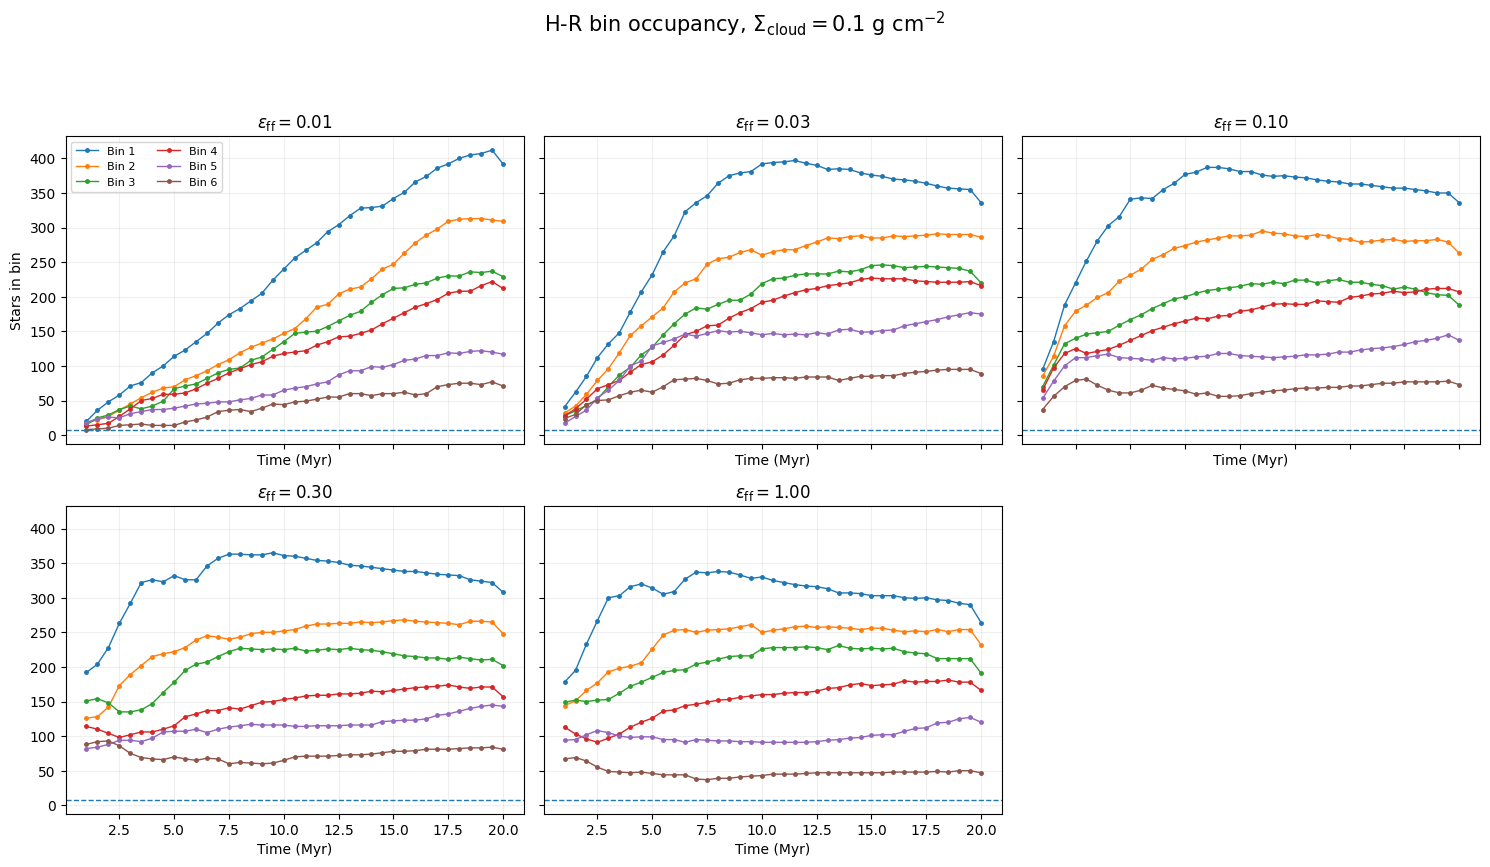

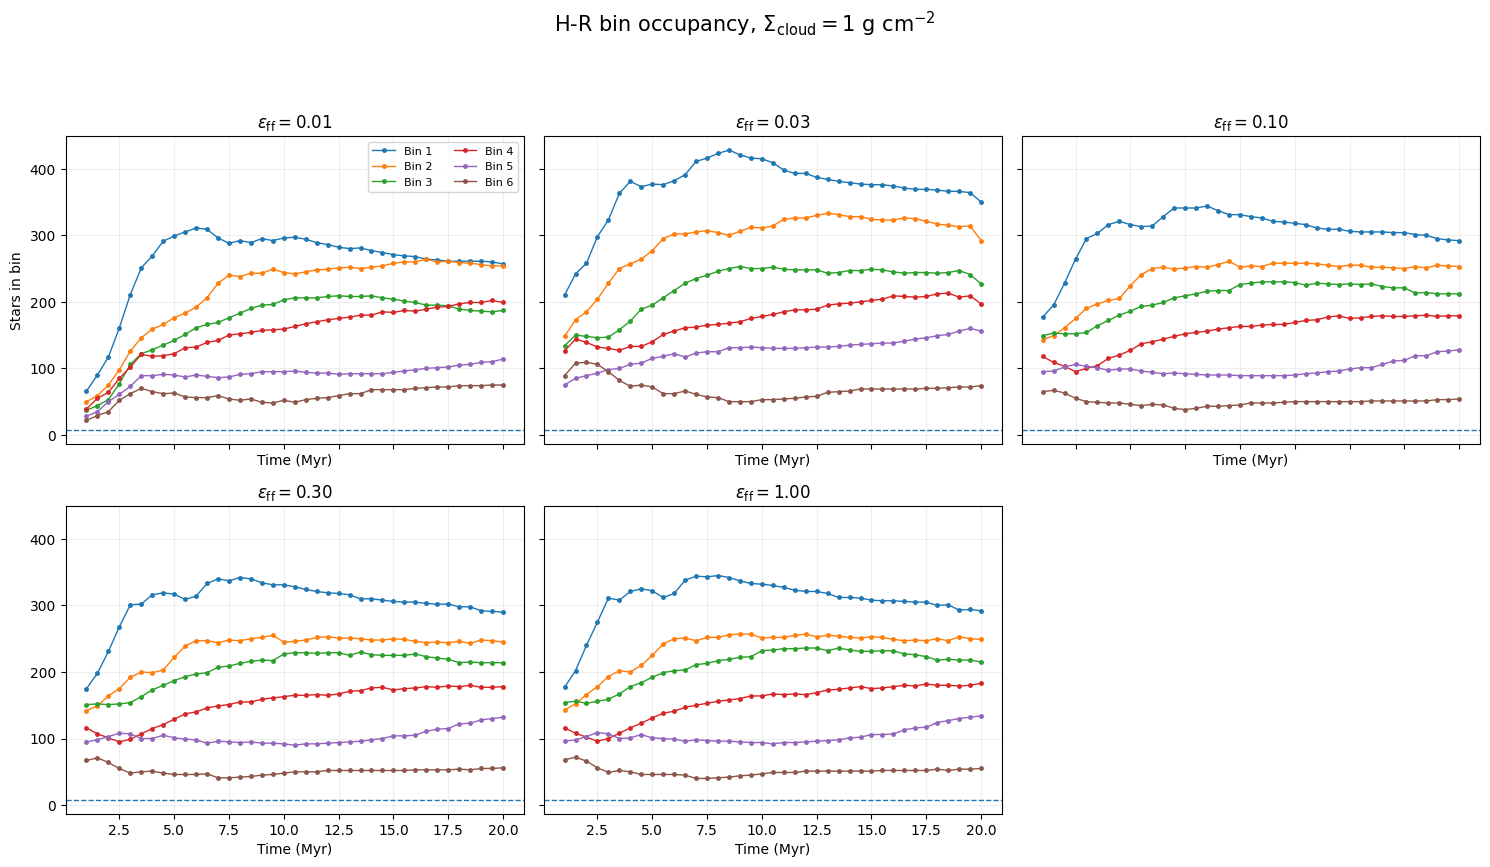

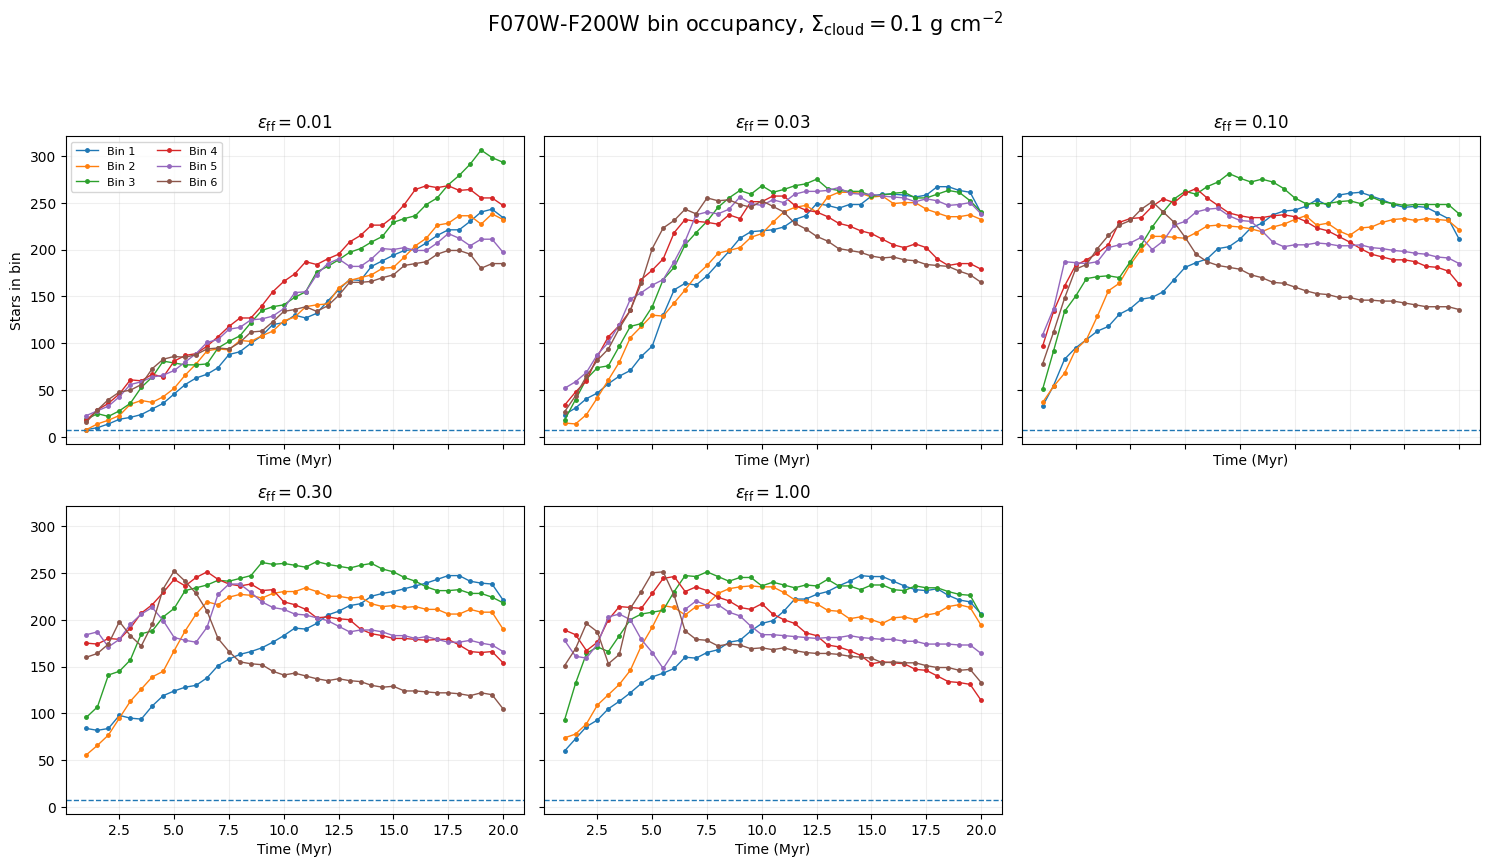

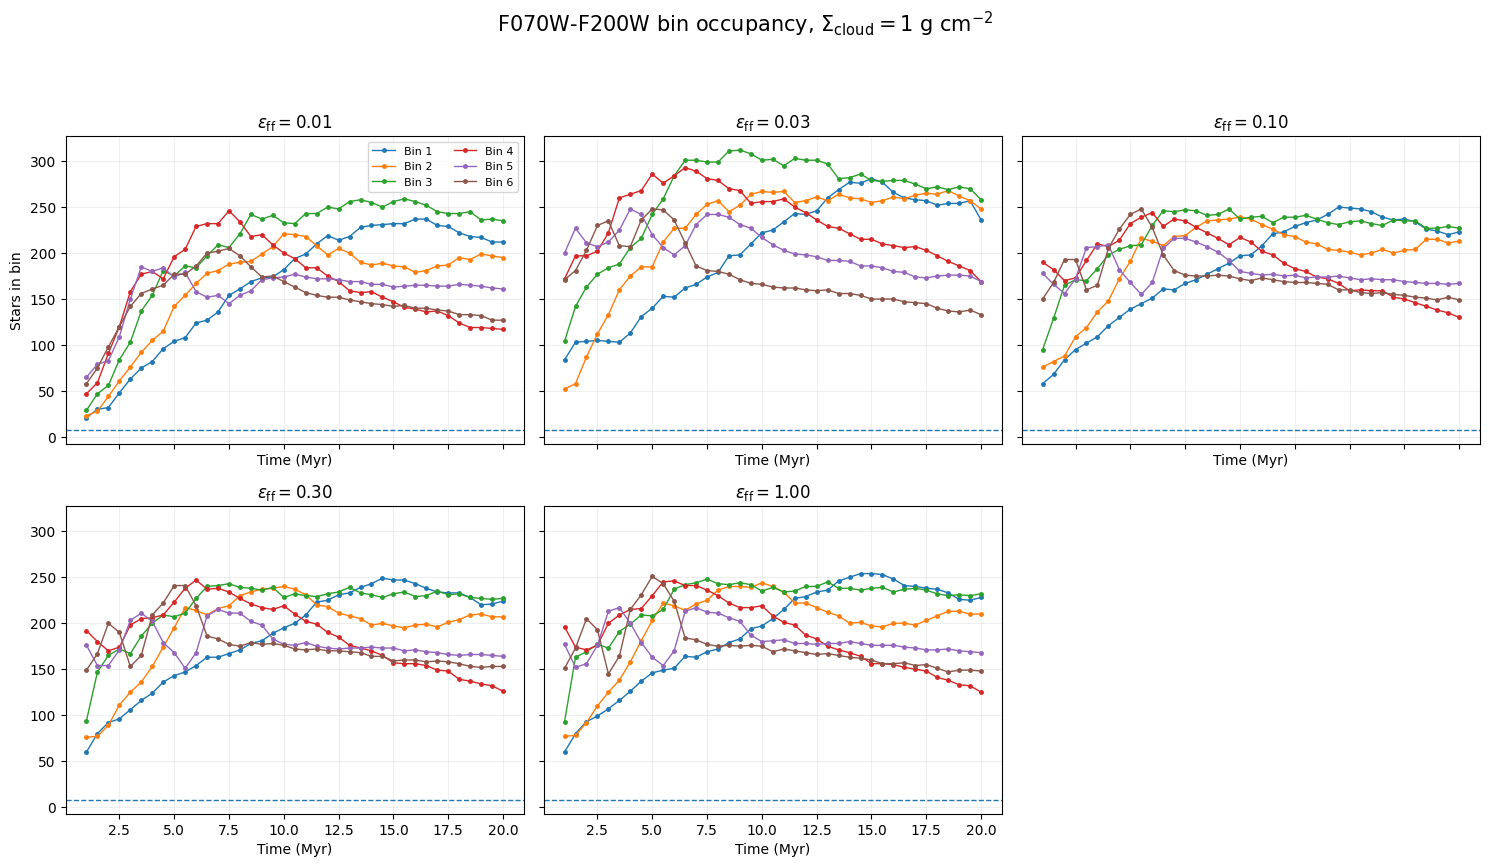

In [19]:
for _space_name in [
    "H-R",
    CMD_NAME,
]:
    for _density in sorted(
        SIGMA_DIRS
    ):
        plot_grouped_bin_occupancy(
            df_spread_bins,
            _space_name,
            _density,
        )

## Final output summary

In [20]:
print("\nAnalysis complete.")
print(f"Isochrone cache: {ISO_CACHE_DIR}")
print(f"Figures and tables: {OUTPUT_DIR}")

print("\nPrimary outputs:")
print("  fixed_bin_edges.csv")
print("  spread_metric_time_series.csv")
print("  spread_metric_by_bin.csv")
print("  snapshot_availability.csv")
print("  grouped_hr_spread_metric.png")
print("  grouped_f070w_f200w_spread_metric.png")
print("  20 cluster-evolution figures")


Analysis complete.
Isochrone cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/07-27_spread-metric-varied-e_ff-sigma/isochrone_cache
Figures and tables: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/07-27_spread-metric-varied-e_ff-sigma/multi_sim_cmd_spread_outputs

Primary outputs:
  fixed_bin_edges.csv
  spread_metric_time_series.csv
  spread_metric_by_bin.csv
  snapshot_availability.csv
  grouped_hr_spread_metric.png
  grouped_f070w_f200w_spread_metric.png
  20 cluster-evolution figures
